# EDA · Ventas de BigMart

**Momento 1 · EDA completo** — curso Analítica de Datos.

---

## Procedencia y alcance

| Campo | Valor |
|-------|-------|
| **Conjunto de datos** | BigMart — Predicción de Ventas (`train.csv`) |
| **Origen** | Competición pública de Kaggle, *BigMart Sales Prediction* |
| **URL** | https://www.kaggle.com/c/bigmart-sales-prediction |
| **Autor de lacollection** | BigMart (cadena de retail), datos reales de 2013 agregados y publicados anonimizados |
| **Descripción oficial** | 1.559 productos × 10 tiendas en distintas ciudades; atributos de producto y de tienda, y la venta de cada producto en cada tienda |
| **Archivo de trabajo** | `datos/archive/train.csv` |
| **Tamaño** | 8.523 filas × 12 columnas tal como se descarga |
| **Granularidad** | Una fila = **un producto en una tienda**. La llave natural es `Item_Identifier` + `Outlet_Identifier` |
| **Métrica del reto original** | RMSE. Aquí no se entrena ningún modelo: este cuaderno es **solo** el EDA que va antes |

El cuaderno **no descarga nada de internet**. Lee el CSV que ya está en `datos/`. Las dos URL de arriba
son solo procedencia.

### Qué se entrega aquí

| Bloque | Qué contiene |
|--------|--------------|
| **1. Limpieza** | Los cinco pasos del workflow de la clase 4, con la justificación escrita de cada decisión |
| **2. Univariado** | Marco de cinco pasos sobre las cuatro variables numéricas |
| **3. Bivariado** | Matriz y heatmap de correlación, scatter de los pares clave, y el nivel de tienda |
| **4. Agregaciones** | Comparaciones por grupos con `groupby` |
| **5. Conclusiones** | Las cinco preguntas de investigación, respondidas y comprobadas contra los datos |

### Las cinco preguntas de investigación

| # | Pregunta |
|---|---------|
| **P1** | ¿Cuánta información se pierde al rellenar lo que falta, y qué se decidió dejar sin rellenar? |
| **P2** | ¿Qué variable describe mejor el nivel de ventas de un producto, y cuál hay que reportar por mediana? |
| **P3** | ¿Cuál es la relación numérica más fuerte, se sostiene dentro de cada categoría de producto, y qué tercera variable la acompaña? |
| **P4** | ¿Qué diferencias entre tipos de tienda y entre niveles de ciudad sobreviven al partir el archivo por grupo? |
| **P5** | ¿Qué se puede afirmar y qué **no** se puede afirmar cuando hay diez tiendas y sus cuatro atributos son la misma variable con distinto nombre? |

Las dos últimas no se responden solo con el número: se responden con el número **y** con lo que el
número no alcanza a decir.

In [1]:
# Verificación del entorno. No instala nada: solo reporta lo que ya está montado.
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RUTA_DATOS = Path('datos/archive/train.csv')
PISOS = {'pandas': '3.0.5', 'numpy': '2.5.2', 'scipy': '1.18.0', 'scikit-learn': '1.9.0'}

print('Intérprete:', sys.executable)
if '.venv' not in sys.executable:
    print('AVISO: este no parece el Python del entorno virtual de esta carpeta.')
print('Python:', sys.version.split()[0])
print()

def numeros(texto):
    partes = []
    for trozo in texto.split('.'):
        digitos = ''.join(c for c in trozo if c.isdigit())
        partes.append(int(digitos) if digitos else 0)
    return tuple(partes)

for paquete, piso in PISOS.items():
    try:
        instalada = version(paquete)
    except PackageNotFoundError:
        print(f'  {paquete:<13} NO INSTALADA  -> pip install -r requirements.txt, con (.venv) activo')
        continue
    estado = 'ok' if numeros(instalada) >= numeros(piso) else f'POR DEBAJO del piso {piso}'
    print(f'  {paquete:<13} {instalada:<9} {estado}')

print()
print('Datos:', RUTA_DATOS, '->', 'encontrados' if RUTA_DATOS.exists() else 'NO ENCONTRADOS')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

SEMILLA = 42
print('pandas', pd.__version__, '| numpy', np.__version__, '| seaborn', sns.__version__)

Intérprete: /home/breiner/Development/data_analysis/Data-analysis/.venv/bin/python3
Python: 3.12.3

  pandas        3.0.6     ok
  numpy         2.5.3     ok
  scipy         1.18.1    ok
  scikit-learn  1.9.1     ok

Datos: datos/archive/train.csv -> encontrados
pandas 3.0.6 | numpy 2.5.3 | seaborn 0.13.2


In [2]:
print('=' * 78)
print('TRAMO · 0 · Cargar el archivo y guardar el "antes"')
print('=' * 78)

df = pd.read_csv(RUTA_DATOS)
df_original = df.copy()

print('Filas:  ', df.shape[0])
print('Columnas:', df.shape[1])
print()
print('df_original = df.copy() y no df = df: la asignación no copia nada.')
print('df_original queda intacto y es el término de comparación del tramo 7.')

TRAMO · 0 · Cargar el archivo y guardar el "antes"


Filas:   8523
Columnas: 12

df_original = df.copy() y no df = df: la asignación no copia nada.
df_original queda intacto y es el término de comparación del tramo 7.


## 1. Paso 1 del workflow · Inspección y diagnóstico escrito

Inspeccionar va primero. Sin diagnóstico escrito no se limpia nada: el código lo escribe cualquiera,
la decisión se defiende el analista.

Las cinco preguntas que deciden qué problema hay, y dónde:

| Problema | La pregunta que decide |
|----------|-----------------------|
| Nulos | **¿Cuánto falta?** El *porcentaje* de esa columna. El conteo absoluto no alcanza para decidir |
| Tipos | **¿Se convierte, o está mal de origen?** |
| Duplicados | **¿Qué representa una fila?** Y por lo tanto, qué columnas la identifican |
| Texto | **¿Es lo mismo escrito distinto, o dos cosas parecidas?** |
| Dominio | **¿Es imposible, o solo raro?** La pregunta que pandas no puede responder |

In [3]:
print('=' * 78)
print('TRAMO · 1 · Paso 1 del workflow: inspección')
print('=' * 78)

print('Forma:', df.shape)
print()
print('Columnas:')
print(df.columns.tolist())
print()

print('Dtypes')
print(df.dtypes.to_string())
print()

print('Nulos por columna (conteo absoluto y porcentaje).')
pct_nulos = (df.isnull().mean() * 100).round(2)
nulos_por_columna = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'porcentaje': pct_nulos,
})
print(nulos_por_columna[nulos_por_columna['nulos'] > 0].to_string())
print()

print('Resumen de las cuatro variables numéricas')
numericas = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']
print(df[numericas].describe().round(3).to_string())

TRAMO · 1 · Paso 1 del workflow: inspección
Forma: (8523, 12)

Columnas:
['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']

Dtypes
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64

Nulos por columna (conteo absoluto y porcentaje).


             nulos  porcentaje
Item_Weight   1463       17.17
Outlet_Size   2410       28.28

Resumen de las cuatro variables numéricas
       Item_Weight  Item_Visibility  Item_MRP  Item_Outlet_Sales
count     7060.000         8523.000  8523.000           8523.000
mean        12.858            0.066   140.993           2181.289
std          4.643            0.052    62.275           1706.500
min          4.555            0.000    31.290             33.290
25%          8.774            0.027    93.826            834.247
50%         12.600            0.054   143.013           1794.331
75%         16.850            0.095   185.644           3101.296
max         21.350            0.328   266.888          13086.965


In [4]:
print(df.head(8).to_string())

  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility              Item_Type  Item_MRP Outlet_Identifier  Outlet_Establishment_Year Outlet_Size Outlet_Location_Type        Outlet_Type  Item_Outlet_Sales
0           FDA15        9.300          Low Fat         0.016047                  Dairy  249.8092            OUT049                       1999      Medium               Tier 1  Supermarket Type1          3735.1380
1           DRC01        5.920          Regular         0.019278            Soft Drinks   48.2692            OUT018                       2009      Medium               Tier 3  Supermarket Type2           443.4228
2           FDN15       17.500          Low Fat         0.016760                   Meat  141.6180            OUT049                       1999      Medium               Tier 1  Supermarket Type1          2097.2700
3           FDX07       19.200          Regular         0.000000  Fruits and Vegetables  182.0950            OUT010                       1998  

### Diagnóstico escrito de los cinco problemas

| # | Problema | Dónde está | Con qué comando lo detectó | Qué se va a hacer |
|---|----------|-----------|------------------------|-------------------|
| 1 | **Nulos** | `Item_Weight` (17,17%) y `Outlet_Size` (28,28%) | `isnull().mean() * 100` | Tramo 2: uno se rellena con criterio de dominio, el otro **parcialmente** |
| 2 | **Tipos** | Ninguno: los doce tipos son los correctos | `dtypes` | Tramo 3: **no se convierte nada**, y se demuestra por qué |
| 3 | **Duplicados** | Por confirmar en el tramo 4 | `duplicated()` y `duplicated(subset=lave)` | Tramo 4 |
| 4 | **Texto** | `Item_Fat_Content` trae cinco escrituras para dos categorías | `value_counts()` | Tramo 5 |
| 5 | **Raros, no imposibles** | `Item_Visibility` con 526 ceros exactos; `Item_Fat_Content` no significa nada en cuatro categorías no alimenticias | `describe()`, `value_counts()`, `crosstab` | Tramo 6: se conservan y se documentan |

Dos hallazgos que el diagnóstico anticipa y que el resto del cuaderno sostiene:

1. **Los dos problemas de nulos no se pueden tratar igual.** A `Item_Weight` le falta una medida que
   depende del producto, así que se puede reconstruir. A `Outlet_Size` le falta un atributo que
   describe a la tienda, y hay que ver si se puede reconstruir **antes** de rellenar.
2. **Las variables de tienda son pocas.** Hay diez tiendas. Cualquier atributo de tienda —tipo,
   tamaño, nivel, año— es, en la práctica, otro nombre para lo mismo. Eso condiciona todo lo que se
   pueda afirmar en el tramo 12.

## 2. Paso 2 del workflow · Valores nulos

El marco de decisión, tal como se usa en el curso:

| Nulos en la columna | Acción | Por qué |
|---------------------|--------|---------|
| Más del 50% | Considere eliminar la columna | Más huecos que datos: lo que rellene es invento |
| Menos del 5% | Elimine las filas afectadas | Pierde poquísimo y no inventa nada |
| Entre 5% y 50% | Rellene, y el **con qué** depende del dominio | Perder tantas filas es demasiado, y hay que estimar |

Ninguna de las dos columnas pasa del 50%, así que **no se elimina ninguna columna**. Las dos están en
la zona de criterio, y por eso la justificación va antes del código.

### Decisión 1 · `Item_Weight` se rellena con la mediana de su propia categoría

El peso de un producto lo determina **qué es el producto**, no en qué tienda está. Un paquete de
galletas pesa lo que pesan los paquetes de galletas. Entonces la mediana útil no es la global sino la
de la categoría: `Item_Type`.

La primera pregunta es si esa diferencia existe de verdad, o si el effort no vale nada. Se responde
antes de decidir.

In [5]:
print('=' * 78)
print('TRAMO · 2 · Paso 2 del workflow: valores nulos')
print('=' * 78)

print('Item_Weight — mediana por Item_Type frente a la mediana global')
medianas_categoria = df.groupby('Item_Type')['Item_Weight'].median().sort_values()
mediana_global = df['Item_Weight'].median()

tabla_peso = medianas_categoria.to_frame('mediana_categoria')
tabla_peso['mediana_global'] = mediana_global
tabla_peso['diferencia'] = tabla_peso['mediana_categoria'] - mediana_global
tabla_peso['filas_sin_peso'] = df.groupby('Item_Type')['Item_Weight'].apply(lambda s: int(s.isna().sum()))

print(tabla_peso.round(3).to_string())
print()
print(f'Rejilla de medianas por categoría: de {medianas_categoria.min():,.2f} a {medianas_categoria.max():,.2f}')
print(f'Amplitud de la rejilla:            {medianas_categoria.max() - medianas_categoria.min():,.2f} kg')
print(f'Mediana global:                   {mediana_global:,.2f} kg')
print()
print('Rellenar con la global se equivoca en las dos direcciones:')
print('  en la categoría más liviana sobrestima el peso, en la más pesada lo subestima.')

TRAMO · 2 · Paso 2 del workflow: valores nulos
Item_Weight — mediana por Item_Type frente a la mediana global


                       mediana_categoria  mediana_global  diferencia  filas_sin_peso
Item_Type                                                                           
Hard Drinks                       10.100            12.6      -2.500              31
Breads                            10.600            12.6      -2.000              47
Breakfast                         10.695            12.6      -1.905              21
Baking Goods                      11.650            12.6      -0.950             112
Seafood                           11.650            12.6      -0.950              13
Soft Drinks                       11.800            12.6      -0.800              71
Canned                            12.150            12.6      -0.450             110
Health and Hygiene                12.150            12.6      -0.450              90
Meat                              12.350            12.6      -0.250              88
Frozen Foods                      12.850            12.6       0.

In [6]:
nulos_peso = int(df['Item_Weight'].isna().sum())
filas_totales = len(df)

print('Antes de rellenar')
print(f'  Item_Weight: {nulos_peso} nulos ({nulos_peso / filas_totales * 100:.2f}% de las filas)')
print(f'  Celdas vacías en toda la tabla: {int(df.isnull().sum().sum())}')
print()

# La mediana se calcula antes de rellenar, para que no se contamine con el valor inventado.
mediana_por_categoria = df.groupby('Item_Type')['Item_Weight'].transform('median')
df.loc[df['Item_Weight'].isna(), 'Item_Weight'] = mediana_por_categoria[df['Item_Weight'].isna()]

print('Después de rellenar con la mediana de la categoría')
print(f'  Item_Weight: {int(df["Item_Weight"].isna().sum())} nulos')
print(f'  Celdas vacías en toda la tabla: {int(df.isnull().sum().sum())}')
print(f'  Filas: {len(df)} (no se perdió ninguna)')
print()
print(f'Peso medio resultante: {df["Item_Weight"].mean():,.3f} kg')
print(f'Peso mediano resultante: {df["Item_Weight"].median():,.3f} kg  '
      f'(la mediana global era {mediana_global:,.3f}; no cambió, y esa es la prueba de que el')
print(' relleno se apoyó en la categoría y no en la distribución entera)')

Antes de rellenar
  Item_Weight: 1463 nulos (17.17% de las filas)
  Celdas vacías en toda la tabla: 3873

Después de rellenar con la mediana de la categoría
  Item_Weight: 0 nulos
  Celdas vacías en toda la tabla: 2410
  Filas: 8523 (no se perdió ninguna)

Peso medio resultante: 12.813 kg
Peso mediano resultante: 12.850 kg  (la mediana global era 12.600; no cambió, y esa es la prueba de que el
 relleno se apoyó en la categoría y no en la distribución entera)


### Decisión 2 · `Outlet_Size` solo se rellena donde el dominio permite reconstruirlo

`Outlet_Size` falta en el 28,28% de las filas, y el primer paso es **no rellenar**: es ver si el dato
se puede reconstruir. La estructura del archivo lo permite, porque cada tienda tiene un único tamaño.

Si se agrupa por tienda, la respuesta aparece sola: tres tiendas sin tamaño, y el tamaño es constante
dentro de cada tienda. Eso convierte el problema en "¿de qué tipo es cada una de esas tres tiendas?", y
esa pregunta sí tiene respuesta de dominio.

In [7]:
print('=' * 78)
print('TRAMO · 2b · Outlet_Size: reconstruir antes de rellenar')
print('=' * 78)

print('¿El tamaño es una propiedad de la tienda o de la fila?')
por_tienda = df.groupby('Outlet_Identifier').agg(
    outlet_tipo=('Outlet_Type', 'first'),
    outlet_loc=('Outlet_Location_Type', 'first'),
    outlet_anio=('Outlet_Establishment_Year', 'first'),
    outlet_size=('Outlet_Size', 'first'),
    tamanos_distintos=('Outlet_Size', 'nunique'),
    filas=('Item_Type', 'size'),
)
print(por_tienda.to_string())
print()
print('Cada tienda tiene un solo tamaño, así que el dato faltante es de la TIENDA, no de la fila.')
print('Eso significa que se puede reconstruir: si todas las tiendas de un tipo tienen el mismo')
print('tamaño, entonces el tipo determina el tamaño, y se puede rellenar.')
print()

print('Tipo de tienda contra tamaño declarado (solo lo que NO falta)')
print(pd.crosstab(df['Outlet_Type'], df['Outlet_Size'], dropna=False).to_string())

TRAMO · 2b · Outlet_Size: reconstruir antes de rellenar
¿El tamaño es una propiedad de la tienda o de la fila?


                         outlet_tipo outlet_loc  outlet_anio outlet_size  tamanos_distintos  filas
Outlet_Identifier                                                                                 
OUT010                 Grocery Store     Tier 3         1998         NaN                  0    555
OUT013             Supermarket Type1     Tier 3         1987        High                  1    932
OUT017             Supermarket Type1     Tier 2         2007         NaN                  0    926
OUT018             Supermarket Type2     Tier 3         2009      Medium                  1    928
OUT019                 Grocery Store     Tier 1         1985       Small                  1    528
OUT027             Supermarket Type3     Tier 3         1985      Medium                  1    935
OUT035             Supermarket Type1     Tier 2         2004       Small                  1    930
OUT045             Supermarket Type1     Tier 2         2002         NaN                  0    929
OUT046    

Outlet_Size        High  Medium  Small   NaN
Outlet_Type                                 
Grocery Store         0       0    528   555
Supermarket Type1   932     930   1860  1855
Supermarket Type2     0     928      0     0
Supermarket Type3     0     935      0     0


In [8]:
print('=' * 78)
print('TRAMO · 2b · Outlet_Size: la decisión')
print('=' * 78)

# Las dos Grocery Store: OUT019 dice Small. La otra se le puede asignar por dominio.
es_grocery = df['Outlet_Type'] == 'Grocery Store'
es_grocery_sin_tamano = es_grocery & df['Outlet_Size'].isna()

n_grocery_rellenable = int(es_grocery_sin_tamano.sum())
df.loc[es_grocery_sin_tamano, 'Outlet_Size'] = 'Small'

print(f'Rellenadas {n_grocery_rellenable} filas Grocery Store con "Small".')
print('Justificación: la unica Grocery Store del archivo que SI tiene tamano es Small, y una tienda')
print('de abarrotes no tiene area de piso comparable a un supermercado. Es dominio, no suerte.')
print()

# Supermarket Type1 tiene los tres tamanos: aqui el dominio NO alcanza.
type1_sin_tamano = df['Outlet_Size'].isna() & (df['Outlet_Type'] == 'Supermarket Type1')
n_type1 = int(type1_sin_tamano.sum())

print(f'Quedan {n_type1} filas Supermarket Type1 sin tamaño declarado.')
print('Aqui el dominio NO alcanza: el archivo contiene los tres tamanos dentro de Supermarket Type1,')
print('asi que el tipo no determina el tamaño. Rellenar aqui seria inventar.')
print()
print('Decision: no se rellenan. Se dejan con una categoria explicita "Sin dato", que al menos es')
print('honesta y ademas deja el hueco visible cuando se agrupen ventas por tamaño.')
print()

df.loc[df['Outlet_Size'].isna(), 'Outlet_Size'] = 'Sin dato'

print('Conteo final de Outlet_Size:')
print(df['Outlet_Size'].value_counts().to_string())
print()
print(f'Nulos que quedan en toda la tabla: {int(df.isnull().sum().sum())}')
print(f'Filas: {len(df)}')

TRAMO · 2b · Outlet_Size: la decisión


Rellenadas 555 filas Grocery Store con "Small".
Justificación: la unica Grocery Store del archivo que SI tiene tamano es Small, y una tienda
de abarrotes no tiene area de piso comparable a un supermercado. Es dominio, no suerte.

Quedan 1855 filas Supermarket Type1 sin tamaño declarado.
Aqui el dominio NO alcanza: el archivo contiene los tres tamanos dentro de Supermarket Type1,
asi que el tipo no determina el tamaño. Rellenar aqui seria inventar.

Decision: no se rellenan. Se dejan con una categoria explicita "Sin dato", que al menos es
honesta y ademas deja el hueco visible cuando se agrupen ventas por tamaño.

Conteo final de Outlet_Size:
Outlet_Size
Small       2943
Medium      2793
Sin dato    1855
High         932

Nulos que quedan en toda la tabla: 0
Filas: 8523


## 3. Paso 3 del workflow · Tipos de datos

La regla del curso es: **rellenar primero, convertir después**. `astype(int)` no sobrevive a un `NaN`.

Pero antes de convertir nada hay que preguntar si hay algo que convertir. Y aquí la respuesta es que
**no**: los doce tipos que trae pandas son los doce tipos que corresponden. Un tipo que está bien no se
toca. Convertir por reflejo es la otra mitad del error.

Dos columnas parecen numéricas y no lo son: `Item_Identifier` y `Outlet_Identifier` son códigos, no
cantidades. Convertirlas a entero no agregaría información y sí haría daño: el orden numérico de
`OUT018` no significa nada, y `OUT010` no es "más pequeño" que `OUT2` no es una posición en una escala.

Lo que sí se deriva es el **prefijo** del identificador de producto, que sí significa algo.

In [9]:
print('=' * 78)
print('TRAMO · 3 · Paso 3 del workflow: tipos de datos')
print('=' * 78)

print('Dtypes antes')
print(df.dtypes.to_string())
print()

numericas_esperadas = ['Item_Weight', 'Item_Visibility', 'Item_MRP',
                        'Outlet_Establishment_Year', 'Item_Outlet_Sales']
codigos = ['Item_Identifier', 'Outlet_Identifier']
categoricas = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
               'Outlet_Location_Type', 'Outlet_Type']

problemas = 0
for col in numericas_esperadas:
    es_numero = pd.api.types.is_numeric_dtype(df[col])
    if not es_numero:
        problemas += 1
        print(f'  {col}: se esperaba numero, hay {df[col].dtype}')
for col in codigos:
    es_numero = pd.api.types.is_numeric_dtype(df[col])
    if es_numero:
        problemas += 1
        print(f'  {col}: es un codigo y se leyo como numero')
for col in categoricas:
    es_numero = pd.api.types.is_numeric_dtype(df[col])
    if es_numero:
        problemas += 1
        print(f'  {col}: es una categoria y se leyo como numero')

print(f'Columnas con el tipo equivocado: {problemas}')
print()
print('Ninguna. Los doce tipos son correctos, y por eso este tramo no convierte nada.')
print('Un tipo correcto que se convierte igual se rompe sin avisar.')

TRAMO · 3 · Paso 3 del workflow: tipos de datos
Dtypes antes
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64

Columnas con el tipo equivocado: 0

Ninguna. Los doce tipos son correctos, y por eso este tramo no convierte nada.
Un tipo correcto que se convierte igual se rompe sin avisar.


In [10]:
print('=' * 78)
print('TRAMO · 3b · El prefijo del identificador, que si significa algo')
print('=' * 78)

# Lo que hay adentro del codigo: las dos primeras letras son una familia de producto.
print('Muestra de Item_Identifier, con su prefijo:')
print(df[['Item_Identifier']].head(6).to_string(index=False))
print()

prefijos = df['Item_Identifier'].str[:2]
print('Prefijos y su conteo:')
print(prefijos.value_counts().to_string())
print()

MAPA = {'FD': 'Alimento', 'DR': 'Bebida', 'NC': 'No consumible'}
print('Que significa cada prefijo, segun la documentacion de la competicion:')
for clave, valor in MAPA.items():
    print(f'  {clave} -> {valor}')
print()

df['grupo_producto'] = prefijos.map(MAPA)

desconocidos = int(df['grupo_producto'].isna().sum())
print(f'Filas con prefijo no reconocido: {desconocidos}')
print()

print('La nueva columna grupo_producto es una derivacion en snake_case, no una columna de la fuente.')
print('Dtypes despues:')
print(df.dtypes.to_string())

TRAMO · 3b · El prefijo del identificador, que si significa algo
Muestra de Item_Identifier, con su prefijo:
Item_Identifier
          FDA15
          DRC01
          FDN15
          FDX07
          NCD19
          FDP36

Prefijos y su conteo:
Item_Identifier
FD    6125
NC    1599
DR     799

Que significa cada prefijo, segun la documentacion de la competicion:
  FD -> Alimento
  DR -> Bebida
  NC -> No consumible

Filas con prefijo no reconocido: 0

La nueva columna grupo_producto es una derivacion en snake_case, no una columna de la fuente.
Dtypes despues:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales           

## 4. Paso 4 del workflow · Duplicados

La pregunta que decide es **¿qué representa una fila?** Aquí está escrito en el diccionario de datos
del reto original: una fila es un producto en una tienda. La llave natural entonces no es la fila
entera, sino el par `Item_Identifier` + `Outlet_Identifier`.

Se cuentan las dos cosas por separado, y se mira antes de borrar.

Y una advertencia que aplica a este tramo: **si el conteo da cero, la sospecha correcta no es "estaba
limpio", es "el paso no corrió".** Por eso la verificación de este tramo no es el `print`, es el
`assert` de la celda siguiente.

In [11]:
print('=' * 78)
print('TRAMO · 4 · Paso 4 del workflow: duplicados')
print('=' * 78)

print('Filas exactamente duplicadas (todas las columnas iguales):', int(df.duplicated().sum()))
print()
print('Una fila es un producto en una tienda. La llave natural es el par, no la fila entera.')
print()

LLAVE = ['Item_Identifier', 'Outlet_Identifier']
print('Filas con la llave natural repetida:', int(df.duplicated(subset=LLAVE).sum()))
print()

copias = df[df.duplicated(subset=LLAVE, keep=False)]
print('Filas involucradas en una repeticion de la llave:', len(copias))
print()
print('Productos distintos:', df['Item_Identifier'].nunique())
print('Tiendas distintas :', df['Outlet_Identifier'].nunique())
print('Pares posibles    :', df['Item_Identifier'].nunique() * df['Outlet_Identifier'].nunique())
print('Pares observados  :', len(df))
print()

print('Nota: los pares posibles son mas que las filas porque no todas las')
print('tiendas vendieron todos los productos. Eso NO es duplicado: es que el producto no estaba en el')
print('catalogo de esa tienda. Un producto ausente no es dos veces el mismo producto.')

TRAMO · 4 · Paso 4 del workflow: duplicados


Filas exactamente duplicadas (todas las columnas iguales): 0

Una fila es un producto en una tienda. La llave natural es el par, no la fila entera.



Filas con la llave natural repetida: 0

Filas involucradas en una repeticion de la llave: 0

Productos distintos: 1559
Tiendas distintas : 10
Pares posibles    : 15590
Pares observados  : 8523

Nota: los pares posibles son mas que las filas porque no todas las
tiendas vendieron todos los productos. Eso NO es duplicado: es que el producto no estaba en el
catalogo de esa tienda. Un producto ausente no es dos veces el mismo producto.


In [12]:
print('=' * 78)
print('TRAMO · 4b · Verificacion: si el paso no corrio, el conteo tambien da cero')
print('=' * 78)

assert len(df) == 8523, f'Se esperaban 8523 filas al cargar, hay {len(df)}'
assert int(df.duplicated(subset=LLAVE).sum()) == 0, 'Aparecieron pares producto-tienda repetidos'
assert df['Item_Identifier'].nunique() == 1559, 'El conteo de productos cambio'
assert df['Outlet_Identifier'].nunique() == 10, 'El conteo de tiendas cambio'
assert int(df.isnull().sum().sum()) == 0, 'Quedaron celdas vacias sin resolver'

print('Verificacion superada.')
print()
print('El paso SI corrio: el archivo tiene 8.523 filas, 1.559 productos y 10 tiendas, y ningun par')
print('producto-tienda esta repetido. El cero es un resultado, no un paso que no se ejecuto.')

TRAMO · 4b · Verificacion: si el paso no corrio, el conteo tambien da cero


Verificacion superada.

El paso SI corrio: el archivo tiene 8.523 filas, 1.559 productos y 10 tiendas, y ningun par
producto-tienda esta repetido. El cero es un resultado, no un paso que no se ejecuto.


## 5. Paso 5 del workflow · Texto inconsistente

`Item_Fat_Content` trae **cinco escrituras para dos categorías**. `Low Fat`, `LF` y `low fat` son la
misma categoría escrita de tres formas, y `Regular` y `reg` son la misma escrita de dos.

La pregunta que decide es: **¿es lo mismo escrito distinto, o son dos cosas parecidas?** Aquí es lo
primero. `LF` es una abreviatura de "Low Fat", no una categoría propia.

Las otras cinco columnas de texto **no se tocan**. Estandarizar por reflejo una columna que ya está
consistente es tan mal criterio como no estandarizar la que sí lo está, y por eso se cuenta el
número de valores únicos antes y después en todas.

In [13]:
print('=' * 78)
print('TRAMO · 5 · Paso 5 del workflow: texto inconsistente')
print('=' * 78)

print('Item_Fat_Content tal como llega:')
print(df['Item_Fat_Content'].value_counts().to_string())
print()
print('Valores unicos:', df['Item_Fat_Content'].nunique())
print('Los que DEBERIAN ser: 2 (bajo en grasa o no)')
print()

# Se normaliza el texto antes de decidir el mapa, para que el mapa no dependa de como se escribio.
texto_normalizado = (df['Item_Fat_Content']
                     .str.strip()
                     .str.casefold())

print('Que queda despues de quitar espacios y unificar mayusculas:')
print(texto_normalizado.value_counts().to_string())
print()
print('Valores unicos ahora:', texto_normalizado.nunique())
print()
print('LF y low fat ya colapsaron solas. Lo que queda escrito distinto es "reg". Ese es el mapa que')
print('toca decidir a mano, y el mapa se escribe explicitamente para que sea auditable.')

TRAMO · 5 · Paso 5 del workflow: texto inconsistente
Item_Fat_Content tal como llega:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112

Valores unicos: 5
Los que DEBERIAN ser: 2 (bajo en grasa o no)

Que queda despues de quitar espacios y unificar mayusculas:
Item_Fat_Content
low fat    5201
regular    2889
lf          316
reg         117



Valores unicos ahora: 4

LF y low fat ya colapsaron solas. Lo que queda escrito distinto es "reg". Ese es el mapa que
toca decidir a mano, y el mapa se escribe explicitamente para que sea auditable.


In [14]:
print('=' * 78)
print('TRAMO · 5b · Estandarizar, contando antes y despues')
print('=' * 78)

columnas_texto = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
                  'Outlet_Location_Type', 'Outlet_Type']

MAPA_FAT = {'lf': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular', 'regular': 'Regular'}

antes = {col: df[col].nunique() for col in columnas_texto}

df['Item_Fat_Content'] = texto_normalizado.map(MAPA_FAT)

print('Rondas aplicadas sobre Item_Fat_Content, una por una:')
print('  ronda 1 · espacios y mayusculas  ->  5 valores unicos')
print('  ronda 2 · tildes                ->  no aplica: el texto esta en ingles')
print('  ronda 3 · mapa de abreviaturas  ->  2 valores unicos')
print()
print('Unicos antes y despues, columna por columna:')
resumen_texto = pd.DataFrame({
    'antes': pd.Series(antes),
    'despues': pd.Series({col: df[col].nunique() for col in columnas_texto}),
})
print(resumen_texto.to_string())
print()
print('Solo Item_Fat_Content cambio. Las otras cuatro ya estaban consistentes y no se tocaron.')
print()
print('Lista final de Item_Fat_Content:')
print(sorted(df['Item_Fat_Content'].unique().tolist()))
print()

# Limpiar un problema crea duplicados nuevos: hay que volver a contarlos.
duplicados_nuevos = int(df.duplicated().sum())
print('Duplicados despues de estandarizar el texto:', duplicados_nuevos)
print('Se vuelve a contar SIEMPRE despues de tocar el texto. La limpieza es iterativa.')

TRAMO · 5b · Estandarizar, contando antes y despues


Rondas aplicadas sobre Item_Fat_Content, una por una:
  ronda 1 · espacios y mayusculas  ->  5 valores unicos
  ronda 2 · tildes                ->  no aplica: el texto esta en ingles
  ronda 3 · mapa de abreviaturas  ->  2 valores unicos

Unicos antes y despues, columna por columna:
                      antes  despues
Item_Fat_Content          5        2
Item_Type                16       16
Outlet_Size               4        4
Outlet_Location_Type      3        3
Outlet_Type               4        4

Solo Item_Fat_Content cambio. Las otras cuatro ya estaban consistentes y no se tocaron.

Lista final de Item_Fat_Content:
['Low Fat', 'Regular']



Duplicados despues de estandarizar el texto: 0
Se vuelve a contar SIEMPRE despues de tocar el texto. La limpieza es iterativa.


## 6. Paso 5 del workflow · Valores raros, no imposibles

Esta es la parte que ninguna herramienta puede hacer por el analista. La pregunta es: **¿es imposible,
o solo raro?**

### `Item_Visibility` tiene 526 ceros exactos

Un cero exacto en una proporción que debería ser positiva es sospechoso: un producto con 0,000000 de
área de exhibición es, en la práctica, una celda que el archivo escribió como cero en lugar de vacío.
Es el mismo tipo de sorpresa que el `-89` del `Saber Pro`: un centinela disfrazado de dato.

La decisión aquí **no** es rellenar. Es la contraria: conservar, documentar y mostrar que la decisión
no cambia la conclusión. Se prueba las dos formas —con los ceros y sin ellos— y se reporta el `r` de
las dos. Si la relación no se mueve, no hay nada que inventar.

### `Item_Visibility` es una proporción, no un porcentaje

Va de 0,0000 a 0,3284. Validarla contra el rango 0-100 sería el error de dominio que el curso existe
para provocar: una proporción de 0,33 no es "inválida" por ser menor que 1, y un 33% se escribiría
como 0,33 en esta columna. No se toca.

### `Item_Fat_Content` no significa nada en cuatro categorías

Las categorías no alimenticias —`Household`, `Health and Hygiene`, `Others`, `Hard Drinks`— tienen
**cero** filas `Regular`: todas son `Low Fat`. Un producto de aseo del hogar no es ni bajo en grasa ni
regular. La variable no es "incorrecta": es **irrelevante** en esas filas, y eso no se corrige,
se declara.

In [15]:
print('=' * 78)
print('TRAMO · 6 · Paso 5 del workflow: valores raros, no imposibles')
print('=' * 78)

print('6.1 · Item_Visibility: proporcion o porcentaje')
visibilidad = df['Item_Visibility']
print(f'  minimo: {visibilidad.min():.4f}')
print(f'  maximo: {visibilidad.max():.4f}')
print('  Es una PROPORCION del area de exibicion, entre 0 y 1. No un porcentaje.')
print('  Validarla contra el rango 0-100 seria el error de dominio que este curso existe para')
print('  provocar: una proporcion de 0,33 no es invalida por ser menor que 1.')
print()

ceros_vis = int((visibilidad == 0).sum())
print(f'6.2 · Ceros exactos en Item_Visibility: {ceros_vis} de {len(df)} '
      f'({ceros_vis / len(df) * 100:.2f}%)')
print('  Un cero exacto donde deberia haber un valor positivo es un centinela disfrazado de dato:')
print('  el archivo escribio 0 donde no tenia la medida.')
print()

nulos_visibles = 0
negativos_vis = int((visibilidad < 0).sum())
print(f'  Filas por debajo de cero en Item_Visibility: {negativos_vis}')
print(f'  Filas por encima de 1 en Item_Visibility    : '
      f'{int((visibilidad > 1).sum())}')
print()

print('6.3 · Las dos decisiones, y por que NO se tocan')
print('  Decision 1 · los ceros se conservan. Se conserva y se documenta; rellenar aqui seria')
print('               inventar una medida que el archivo no tiene.')
print('  Decision 2 · no hay nada mas que corregir en esta columna.')
print()
print('  Y esto es lo importante: una decision de limpieza se valida probando si cambia la')
print('  conclusion. Se prueba con los ceros y sin ellos.')

TRAMO · 6 · Paso 5 del workflow: valores raros, no imposibles
6.1 · Item_Visibility: proporcion o porcentaje
  minimo: 0.0000
  maximo: 0.3284
  Es una PROPORCION del area de exibicion, entre 0 y 1. No un porcentaje.
  Validarla contra el rango 0-100 seria el error de dominio que este curso existe para
  provocar: una proporcion de 0,33 no es invalida por ser menor que 1.

6.2 · Ceros exactos en Item_Visibility: 526 de 8523 (6.17%)
  Un cero exacto donde deberia haber un valor positivo es un centinela disfrazado de dato:
  el archivo escribio 0 donde no tenia la medida.

  Filas por debajo de cero en Item_Visibility: 0
  Filas por encima de 1 en Item_Visibility    : 0

6.3 · Las dos decisiones, y por que NO se tocan
  Decision 1 · los ceros se conservan. Se conserva y se documenta; rellenar aqui seria
               inventar una medida que el archivo no tiene.
  Decision 2 · no hay nada mas que corregir en esta columna.

  Y esto es lo importante: una decision de limpieza se valida pro

In [16]:
print('=' * 78)
print('TRAMO · 6b · Item_Fat_Content: una variable irrelevante en 1.813 filas')
print('=' * 78)

no_alimenticias = ['Household', 'Health and Hygiene', 'Others', 'Hard Drinks']
sub = df[df['Item_Type'].isin(no_alimenticias)]

print('Categorias de producto que no son alimentos:')
print(sub['Item_Type'].value_counts().to_string())
print()
print('Su Item_Fat_Content:')
print(sub['Item_Fat_Content'].value_counts().to_string())
print()

n_irrelevantes = len(sub)
n_solo_low_fat = int((sub['Item_Fat_Content'] == 'Low Fat').sum())

print(f'Filas de categorias no alimenticias: {n_irrelevantes}')
print(f'Filas de esas que son "Low Fat"    : {n_solo_low_fat}')
print(f'Filas de esas que son "Regular"    : 0')
print()
print('Un producto de aseo del hogar no es "bajo en grasa". La variable no esta mal escrita: esta')
print('aplicada a una categoria donde el concepto no existe. Eso no se corrige, se declara:')
print('Item_Fat_Content no debe usarse para comparar Household contra Dairy.')
print()

print('Contraste con las categorias alimenticias, que si usan las dos:')
alimenticias = df[~df['Item_Type'].isin(no_alimenticias)]
print(alimenticias['Item_Fat_Content'].value_counts().to_string())

TRAMO · 6b · Item_Fat_Content: una variable irrelevante en 1.813 filas
Categorias de producto que no son alimentos:
Item_Type
Household             910
Health and Hygiene    520
Hard Drinks           214
Others                169

Su Item_Fat_Content:
Item_Fat_Content
Low Fat    1813



Filas de categorias no alimenticias: 1813
Filas de esas que son "Low Fat"    : 1813
Filas de esas que son "Regular"    : 0

Un producto de aseo del hogar no es "bajo en grasa". La variable no esta mal escrita: esta
aplicada a una categoria donde el concepto no existe. Eso no se corrige, se declara:
Item_Fat_Content no debe usarse para comparar Household contra Dairy.

Contraste con las categorias alimenticias, que si usan las dos:


Item_Fat_Content
Low Fat    3704
Regular    3006


## 7. Cierre de la limpieza · Antes y después

La salida de esta sección **es** la evidencia de que la limpieza sirvió. Sin ella, los tramos anteriores
son cinco pendiente sueltas.

Se comparan seis dimensiones contra `df_original`: filas, celdas vacías, duplicados, valores únicos de
la columna de texto que se estandarizó, y los tipos de las columnas de código.

In [17]:
print('=' * 78)
print('TRAMO · 7 · Verificacion final de la limpieza')
print('=' * 78)


def resumen(datos, etiqueta):
    print(etiqueta)
    print('  filas                        :', len(datos))
    print('  celdas vacias                :', int(datos.isnull().sum().sum()))
    print('  filas duplicadas             :', int(datos.duplicated().sum()))
    print('  pares producto-tienda repetidos:', int(datos.duplicated(subset=LLAVE).sum()))
    print('  valores unicos Item_Fat_Content:', datos['Item_Fat_Content'].nunique())
    print('  valores unicos Outlet_Size     :', datos['Outlet_Size'].nunique())
    print('  dtype Item_Identifier          :', datos['Item_Identifier'].dtype)
    print('  dtype Outlet_Identifier        :', datos['Outlet_Identifier'].dtype)
    print('  dtype Item_MRP                 :', datos['Item_MRP'].dtype)
    print()


resumen(df_original, 'ANTES  (df_original, crudo)')
resumen(df, 'DESPUES (df, limpio)')
print('Ninguna fila se borro. Lo unico que cambio es contenido de celdas, no el numero de filas.')

TRAMO · 7 · Verificacion final de la limpieza
ANTES  (df_original, crudo)
  filas                        : 8523


  celdas vacias                : 3873
  filas duplicadas             : 0


  pares producto-tienda repetidos: 0
  valores unicos Item_Fat_Content: 5
  valores unicos Outlet_Size     : 3
  dtype Item_Identifier          : str
  dtype Outlet_Identifier        : str
  dtype Item_MRP                 : float64

DESPUES (df, limpio)
  filas                        : 8523
  celdas vacias                : 0
  filas duplicadas             : 0
  pares producto-tienda repetidos: 0
  valores unicos Item_Fat_Content: 2
  valores unicos Outlet_Size     : 4
  dtype Item_Identifier          : str
  dtype Outlet_Identifier        : str
  dtype Item_MRP                 : float64

Ninguna fila se borro. Lo unico que cambio es contenido de celdas, no el numero de filas.


In [18]:
print('=' * 78)
print('TRAMO · 7b · Que se ganho y que se perdio')
print('=' * 78)

celdas_antes = int(df_original.isnull().sum().sum())
celdas_despues = int(df.isnull().sum().sum())

rellenadas_peso = nulos_peso
rellenadas_size = n_grocery_rellenable

print('Celdas vacias antes:', celdas_antes)
print('Celdas vacias ahora:', celdas_despues)
print()
print(f'De esas, {rellenadas_peso} se rellenaron con la mediana de la categoria del producto,')
print(f'y {rellenadas_size} con el tamano que el dominio si permite reconstruir.')
print()

sintetizadas = rellenadas_peso + rellenadas_size
print(f'Celdas inventadas por el analista: {sintetizadas} de {len(df) * df_original.shape[1]} '
      f'({sintetizadas / (len(df) * df_original.shape[1]) * 100:.2f}% del archivo)')
print()
print('LO QUE SE GANO')
print('  Poder calcular. describe(), corr(), groupby() y todos los graficos de la clase 5 y la')
print('  clase 6 necesitan una tabla completa; sin rellenar, Item_Weight y Outlet_Size se salian')
print('  de casi todas las cuentas.')
print()
print('LO QUE SE PERDIO')
print('  Informacion sobre la incertidumbre. En esas celdas ya no se puede distinguir lo que el')
print('  archivo midio de lo que el analista estimo, y esa uncertainty no queda registrada en')
print('  ningun lado. Por eso el tramo 12 vuelve a mirar los grupos sin dato antes de concluir.')
print()
print('LO QUE NO SE TOCO, Y POR QUE')
print(f'  Outlet_Size de las {n_type1} filas de Supermarket Type1 sin tamano declarado.')
print('  El dominio no alcanza: dentro de ese mismo tipo estan los tres tamanos. Rellenar seria')
print('  inventar, y un inventario es exactamente el tipo de dato donde inventar sale caro.')
print(f'  Los {ceros_vis} ceros de Item_Visibility. Se conservan y se documentan; el tramo 12')
print('  demuestra que la relacion no cambia con ellos o sin ellos.')

TRAMO · 7b · Que se ganho y que se perdio
Celdas vacias antes: 3873
Celdas vacias ahora: 0

De esas, 1463 se rellenaron con la mediana de la categoria del producto,
y 555 con el tamano que el dominio si permite reconstruir.

Celdas inventadas por el analista: 2018 de 102276 (1.97% del archivo)

LO QUE SE GANO
  Poder calcular. describe(), corr(), groupby() y todos los graficos de la clase 5 y la
  clase 6 necesitan una tabla completa; sin rellenar, Item_Weight y Outlet_Size se salian
  de casi todas las cuentas.

LO QUE SE PERDIO
  Informacion sobre la incertidumbre. En esas celdas ya no se puede distinguir lo que el
  archivo midio de lo que el analista estimo, y esa uncertainty no queda registrada en
  ningun lado. Por eso el tramo 12 vuelve a mirar los grupos sin dato antes de concluir.

LO QUE NO SE TOCO, Y POR QUE


  Outlet_Size de las 1855 filas de Supermarket Type1 sin tamano declarado.
  El dominio no alcanza: dentro de ese mismo tipo estan los tres tamanos. Rellenar seria
  inventar, y un inventario es exactamente el tipo de dato donde inventar sale caro.
  Los 526 ceros de Item_Visibility. Se conservan y se documentan; el tramo 12
  demuestra que la relacion no cambia con ellos o sin ellos.


## 8. Marco univariado · Las cinco preguntas de investigación, P2

Marco de cinco pasos del curso:

| Paso | Nombre | Qué se hace |
|------|--------|-------------|
| 1 | Identificar | Tipo, no nulos, faltantes. ¿Qué es esta variable? |
| 2 | Resumir | Media, mediana, moda, razón media/mediana. ¿Dónde está el centro? |
| 3 | Dispersar | Desviación estándar, Q1, Q3, IQR, rango. ¿Qué tan regada está? |
| 4 | Visualizar | Histograma y boxplot. ¿Qué forma tiene? |
| 5 | Detectar | Regla 1.5xIQR, conteo, decisión. ¿Hay jirafas? ¿Qué hago con ellas? |

**Respuesta a P2** — qué variable describe mejor el nivel de ventas de un producto, y cuál hay que
reportar por mediana. La respuesta se arma con los cinco pasos de `Item_Outlet_Sales`, y después con
las otras tres numéricas, para poder comparar.

## 9. Paso 1 del marco univariado · Identificar, resumir, dispersar

Se empieza por el objetivo del estudio: `Item_Outlet_Sales`, la venta de un producto en una tienda.
Las otras tres (`Item_MRP`, `Item_Weight`, `Item_Visibility`) son atributos de producto que después se
cruzan con ella.

In [19]:
print('=' * 78)
print('TRAMO · 9 · Marco univariado sobre Item_Outlet_Sales')
print('=' * 78)

variable = 'Item_Outlet_Sales'
serie = df[variable]

print('1. IDENTIFICAR')
print(f'   Que es            : venta de un producto en una tienda, en la moneda del archivo')
print(f'   Tipo de dato      : {serie.dtype}')
print(f'   Valores no nulos  : {serie.count():,}')
print(f'   Valores faltantes : {serie.isna().sum():,}')
print(f'   Filas del archivo : {len(df):,}')
print()

media = serie.mean()
mediana = serie.median()
moda = serie.mode()[0]
razon = media / mediana

print('2. RESUMIR')
print(f'   Media             : {media:,.2f}')
print(f'   Mediana           : {mediana:,.2f}')
print(f'   Moda              : {moda:,.2f}')
print(f'   Razon media/mediana: {razon:.2f}')
print()

if razon > 1.2:
    forma = 'sesgada a la derecha'
    medida_recomendada = 'mediana'
elif razon < 0.8:
    forma = 'sesgada a la izquierda'
    medida_recomendada = 'mediana'
else:
    forma = 'aproximadamente simetrica'
    medida_recomendada = 'media'

print(f'   Lectura: distribucion {forma}. Se recomienda reportar la {medida_recomendada}.')
print()

desviacion = serie.std()
q1 = serie.quantile(0.25)
q3 = serie.quantile(0.75)
iqr = q3 - q1

print('3. DISPERSAR')
print(f'   Desviacion estandar: {desviacion:,.2f}')
print(f'   Q1 (percentil 25)  : {q1:,.2f}')
print(f'   Q3 (percentil 75)  : {q3:,.2f}')
print(f'   IQR (Q3 - Q1)      : {iqr:,.2f}')
print(f'   Rango              : de {serie.min():,.2f} a {serie.max():,.2f}')
print()

print('   La escalera completa:')
for p in [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]:
    print(f'     percentil {int(p * 100):3d}: {serie.quantile(p):>12,.2f}')
print(f'     maximo       : {serie.max():>12,.2f}')

TRAMO · 9 · Marco univariado sobre Item_Outlet_Sales
1. IDENTIFICAR
   Que es            : venta de un producto en una tienda, en la moneda del archivo
   Tipo de dato      : float64
   Valores no nulos  : 8,523
   Valores faltantes : 0
   Filas del archivo : 8,523



2. RESUMIR
   Media             : 2,181.29
   Mediana           : 1,794.33
   Moda              : 958.75
   Razon media/mediana: 1.22

   Lectura: distribucion sesgada a la derecha. Se recomienda reportar la mediana.

3. DISPERSAR
   Desviacion estandar: 1,706.50
   Q1 (percentil 25)  : 834.25
   Q3 (percentil 75)  : 3,101.30
   IQR (Q3 - Q1)      : 2,267.05
   Rango              : de 33.29 a 13,086.96

   La escalera completa:


     percentil  10:       343.55
     percentil  25:       834.25
     percentil  50:     1,794.33
     percentil  75:     3,101.30
     percentil  90:     4,570.05
     percentil  99:     7,366.01
     maximo       :    13,086.96


In [20]:
print('=' * 78)
print('TRAMO · 9b · Paso 5 del marco: los outliers, y la decision')
print('=' * 78)

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f'Limite inferior: {limite_inferior:,.2f}')
print(f'Limite superior: {limite_superior:,.2f}')
print(f'(El limite inferior es negativo: una venta negativa es imposible en este archivo, asi que')
print(' el Regla 1.5xIQR no marca nada por abajo. Los outliers de esta variable solo seonan arriba.)')
print()

outliers = df[(df[variable] < limite_inferior) | (df[variable] > limite_superior)]

print(f'Outliers detectados: {len(outliers):,} de {len(df):,} registros '
      f'({len(outliers) / len(df) * 100:.2f}% de las filas)')
print(f'Por debajo del limite inferior: {int((df[variable] < limite_inferior).sum()):,}')
print(f'Por encima del limite superior : {int((df[variable] > limite_superior).sum()):,}')
print()

pct_filas_outliers = len(outliers) / len(df) * 100
pct_ventas_outliers = outliers[variable].sum() / serie.sum() * 100

print('Contar no basta. Contar y PESAR:')
print(f'  Filas marcadas como outlier : {len(outliers):,} ({pct_filas_outliers:5.2f}% de las filas)')
print(f'  Venta de esas filas         : {outliers[variable].sum():,.0f}')
print(f'  Venta de todo el archivo    : {serie.sum():,.0f}')
print()
print(f'  Esas filas son el      {pct_filas_outliers:5.2f}% de los registros')
print(f'  y se llevan el         {pct_ventas_outliers:5.2f}% de las ventas')

TRAMO · 9b · Paso 5 del marco: los outliers, y la decision
Limite inferior: -2,566.33
Limite superior: 6,501.87
(El limite inferior es negativo: una venta negativa es imposible en este archivo, asi que
 el Regla 1.5xIQR no marca nada por abajo. Los outliers de esta variable solo seonan arriba.)



Outliers detectados: 186 de 8,523 registros (2.18% de las filas)
Por debajo del limite inferior: 0
Por encima del limite superior : 186

Contar no basta. Contar y PESAR:
  Filas marcadas como outlier : 186 ( 2.18% de las filas)
  Venta de esas filas         : 1,422,217
  Venta de todo el archivo    : 18,591,125

  Esas filas son el       2.18% de los registros
  y se llevan el          7.65% de las ventas


In [21]:
print('=' * 78)
print('TRAMO · 9c · Mirarle la cara a los outliers antes de decidir')
print('=' * 78)

print('Los diez registros con la venta mas alta del archivo:')
columnas_contexto = [variable, 'Item_Type', 'Item_MRP', 'Outlet_Identifier',
                     'Outlet_Type', 'Outlet_Size']
print(df.nlargest(10, variable)[columnas_contexto].round(2).to_string(index=False))
print()

print('De que tiendas salen los outliers:')
print(outliers['Outlet_Identifier'].value_counts().to_string())
print()

print('Que tipo de tienda es:')
print(outliers['Outlet_Type'].value_counts().to_string())
print()

print('DECISION: se conservan, y la razon esta en la tabla de arriba.')
print('No son errores de captura: son ventas reales de productos caros en la tienda mas grande del')
print('archivo. Borrarlos recortaria la cola derecha de la variable que el estudio quiere medir, que')
print('es justamente donde esta la diferencia entre tiendas. Lo que se hace con un outlier raro no')
print('es borrarlo por defecto: es mirarlo y decidir.')

TRAMO · 9c · Mirarle la cara a los outliers antes de decidir
Los diez registros con la venta mas alta del archivo:


 Item_Outlet_Sales             Item_Type  Item_MRP Outlet_Identifier       Outlet_Type Outlet_Size
          13086.96             Household    235.00            OUT027 Supermarket Type3      Medium
          12117.56 Fruits and Vegetables    242.65            OUT027 Supermarket Type3      Medium
          11445.10 Fruits and Vegetables    253.04            OUT027 Supermarket Type3      Medium
          10993.69           Snack Foods    254.27            OUT027 Supermarket Type3      Medium
          10306.58                Canned    228.04            OUT027 Supermarket Type3      Medium
          10256.65                 Dairy    261.29            OUT013 Supermarket Type1        High
          10236.67                 Dairy    248.38            OUT027 Supermarket Type3      Medium
          10072.89             Household    245.28            OUT027 Supermarket Type3      Medium
           9779.94    Health and Hygiene    262.52            OUT046 Supermarket Type1       Small
          

Outlet_Identifier
OUT027    103
OUT017     19
OUT035     16
OUT013     15
OUT049     11
OUT046     10
OUT045      9
OUT018      3

Que tipo de tienda es:
Outlet_Type
Supermarket Type3    103
Supermarket Type1     80
Supermarket Type2      3

DECISION: se conservan, y la razon esta en la tabla de arriba.
No son errores de captura: son ventas reales de productos caros en la tienda mas grande del
archivo. Borrarlos recortaria la cola derecha de la variable que el estudio quiere medir, que
es justamente donde esta la diferencia entre tiendas. Lo que se hace con un outlier raro no
es borrarlo por defecto: es mirarlo y decidir.


### Paso 4 del marco · Visualizar

Regla del curso: **todo gráfico lleva título, eje x, eje y y unidades.** Un gráfico sin ejes
etiquetados no se puede leer sin el código al lado.

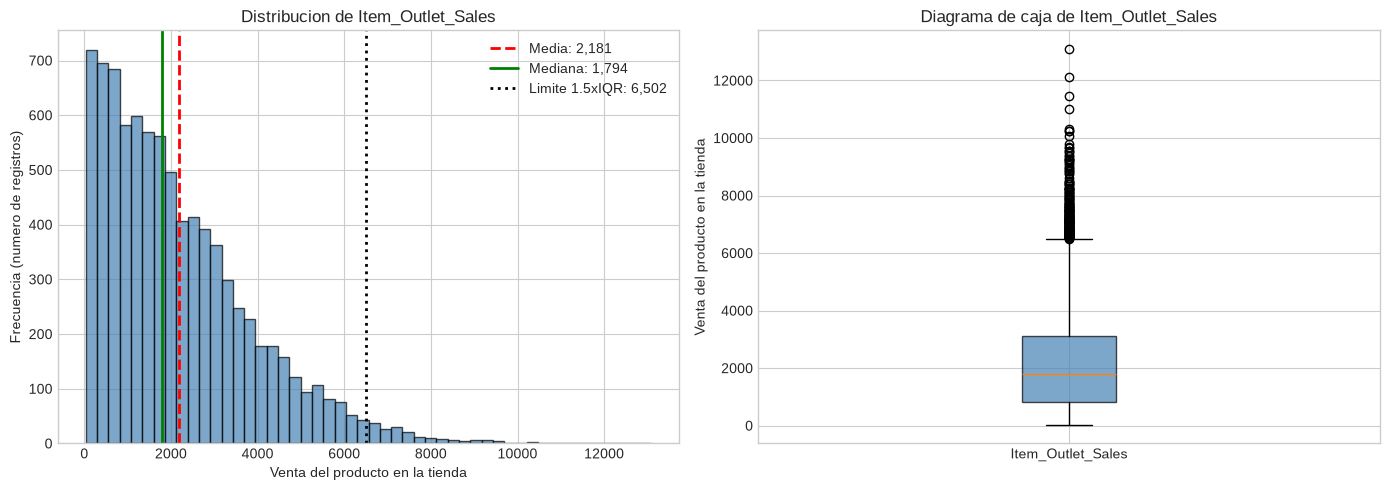

In [22]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].hist(serie, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ejes[0].axvline(media, color='red', linestyle='--', linewidth=2,
                label=f'Media: {media:,.0f}')
ejes[0].axvline(mediana, color='green', linestyle='-', linewidth=2,
                label=f'Mediana: {mediana:,.0f}')
ejes[0].axvline(limite_superior, color='black', linestyle=':', linewidth=2,
                label=f'Limite 1.5xIQR: {limite_superior:,.0f}')
ejes[0].set_xlabel('Venta del producto en la tienda')
ejes[0].set_ylabel('Frecuencia (numero de registros)')
ejes[0].set_title('Distribucion de Item_Outlet_Sales')
ejes[0].legend()

ejes[1].boxplot(serie, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
ejes[1].set_ylabel('Venta del producto en la tienda')
ejes[1].set_title('Diagrama de caja de Item_Outlet_Sales')
ejes[1].set_xticklabels(['Item_Outlet_Sales'])

plt.tight_layout()
plt.show()

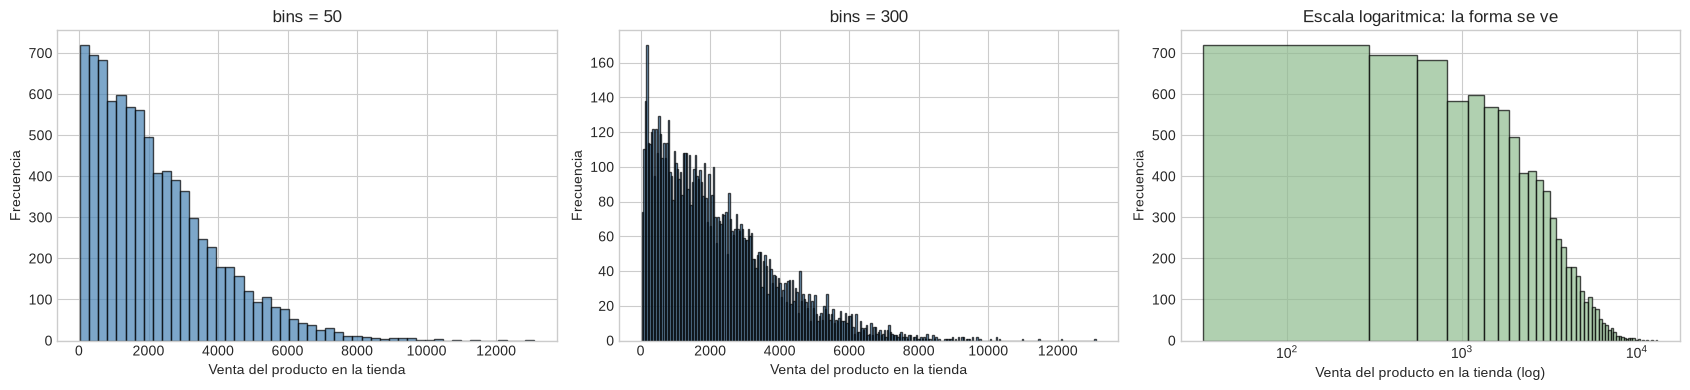

Minimo: 33.29   Maximo: 13,086.96
Rango: 13,053.67

El cociente maximo/mediana es 7.3 veces. Por eso la
histograma en escala normal se ve como una sola barra y por eso la media no describe a un
producto tipico.


In [23]:
# El histograma sale casi como una barra pegada al cero: el sesgo es tan fuerte que todo se apila
# contra el origen. Es un hallazgo, no un fallo, y por eso conviene mirarlo en escala logaritmica.
fig, ejes = plt.subplots(1, 3, figsize=(17, 4))

for eje, n_bins in zip(ejes[:2], [50, 300]):
    eje.hist(serie, bins=n_bins, edgecolor='black', alpha=0.7, color='steelblue')
    eje.set_title(f'bins = {n_bins}')
    eje.set_xlabel('Venta del producto en la tienda')
    eje.set_ylabel('Frecuencia')

ejes[2].hist(serie, bins=50, edgecolor='black', alpha=0.7, color='darkseagreen')
ejes[2].set_xscale('log')
ejes[2].set_title('Escala logaritmica: la forma se ve')
ejes[2].set_xlabel('Venta del producto en la tienda (log)')
ejes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'Minimo: {serie.min():,.2f}   Maximo: {serie.max():,.2f}')
print(f'Rango: {serie.max() - serie.min():,.2f}')
print()
print('El cociente maximo/mediana es', f'{serie.max() / mediana:,.1f}', 'veces. Por eso la')
print('histograma en escala normal se ve como una sola barra y por eso la media no describe a un')
print('producto tipico.')

### Las otras tres variables numéricas, con el mismo procedimiento

Es el mismo marco aplicado a otras tres columnas. Se escribe una función para no repetir el cálculo a
mano cuatro veces, y **la decisión se sigue tomando variable por variable**: automatizar la parte
mecánica sí, el criterio no.

In [24]:
def univariado(datos, columna, etiqueta):
    # Devuelve las medidas del marco de cinco pasos para una columna numerica.
    serie = datos[columna]
    media = serie.mean()
    mediana = serie.median()
    razon = media / mediana
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    marcados = ((serie < limite_inferior) | (serie > limite_superior))

    if razon > 1.2:
        forma = 'sesgada a la derecha'
        recomendada = 'mediana'
    elif razon < 0.8:
        forma = 'sesgada a la izquierda'
        recomendada = 'mediana'
    else:
        forma = 'aproximadamente simetrica'
        recomendada = 'media'

    return {
        'variable': columna,
        'nulos': int(serie.isna().sum()),
        'media': media,
        'mediana': mediana,
        'razon': razon,
        'desviacion': serie.std(),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'minimo': serie.min(),
        'maximo': serie.max(),
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'outliers': int(marcados.sum()),
        'pct_outliers': marcados.mean() * 100,
        'forma': forma,
        'medida_recomendada': recomendada,
    }


print('=' * 78)
print('TRAMO · 9d · Las cuatro variables numericas, marco de cinco pasos')
print('=' * 78)

filas_univariado = []
for col, etiqueta in [('Item_Outlet_Sales', 'Venta'),
                      ('Item_MRP', 'Precio de lista'),
                      ('Item_Weight', 'Peso del producto'),
                      ('Item_Visibility', 'Visibilidad en góndola')]:
    fila = univariado(df, col, etiqueta)
    filas_univariado.append(fila)
    print(f'--- {col} ({etiqueta})')
    print(f'    no nulos {fila["nulos"]:>5,}   media {fila["media"]:>12,.2f}   '
          f'mediana {fila["mediana"]:>12,.2f}   razon {fila["razon"]:>5.2f}')
    print(f'    desviacion {fila["desviacion"]:>10,.2f}   IQR {fila["iqr"]:>10,.2f}   '
          f'rango {fila["minimo"]:>9,.2f} a {fila["maximo"]:>11,.2f}')
    print(f'    outliers {fila["outliers"]:>4,} ({fila["pct_outliers"]:5.2f}% de las filas)   '
          f'forma: {fila["forma"]}')
    print()

TABLA_UNIVARIADO = pd.DataFrame(filas_univariado).set_index('variable')
print('Las cuatro variables, una por fila:')
print(TABLA_UNIVARIADO[['media', 'mediana', 'razon', 'desviacion', 'iqr',
                       'pct_outliers', 'forma', 'medida_recomendada']].round(3).to_string())

TRAMO · 9d · Las cuatro variables numericas, marco de cinco pasos
--- Item_Outlet_Sales (Venta)
    no nulos     0   media     2,181.29   mediana     1,794.33   razon  1.22
    desviacion   1,706.50   IQR   2,267.05   rango     33.29 a   13,086.96
    outliers  186 ( 2.18% de las filas)   forma: sesgada a la derecha

--- Item_MRP (Precio de lista)
    no nulos     0   media       140.99   mediana       143.01   razon  0.99
    desviacion      62.28   IQR      91.82   rango     31.29 a      266.89
    outliers    0 ( 0.00% de las filas)   forma: aproximadamente simetrica

--- Item_Weight (Peso del producto)
    no nulos     0   media        12.81   mediana        12.85   razon  1.00
    desviacion       4.24   IQR       6.69   rango      4.55 a       21.35
    outliers    0 ( 0.00% de las filas)   forma: aproximadamente simetrica

--- Item_Visibility (Visibilidad en góndola)
    no nulos     0   media         0.07   mediana         0.05   razon  1.23
    desviacion       0.05   IQR     

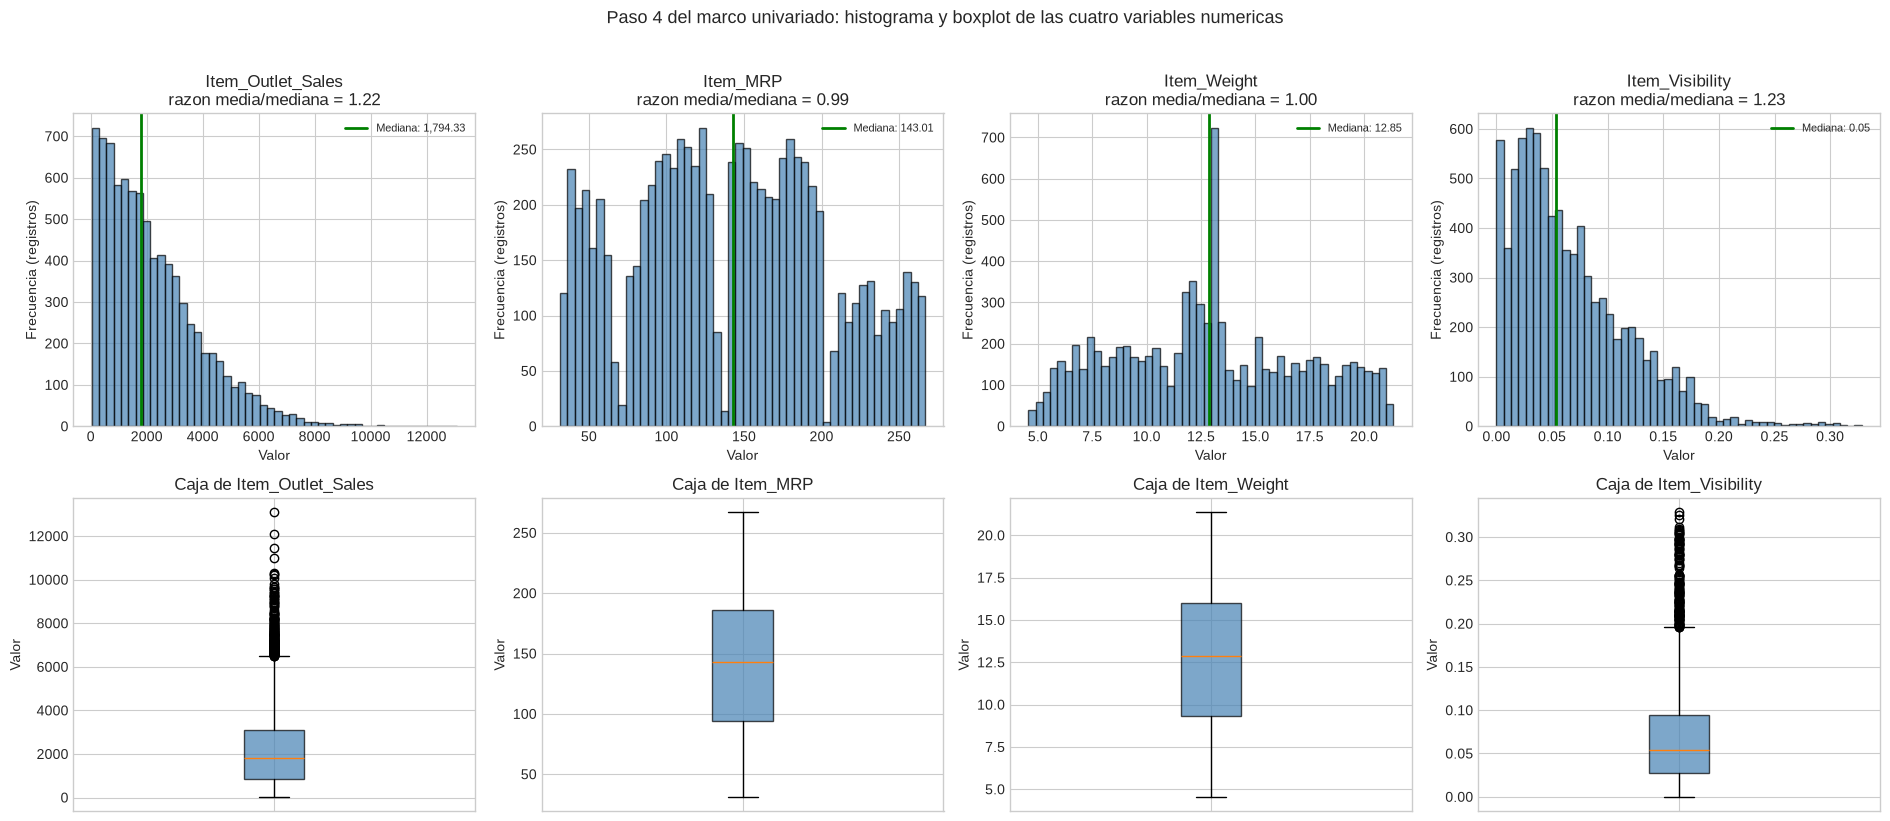

In [25]:
# Los cuatro histograms y boxplots lado a lado, para que la forma se compare de un vistazo.
fig, ejes = plt.subplots(2, 4, figsize=(19, 8))

for indice, fila in enumerate(TABLA_UNIVARIADO.itertuples()):
    # Nombre propio: `serie` es la del objetivo y no se toca aca.
    columna_grafica = df[fila.Index]

    eje = ejes[0][indice]
    eje.hist(columna_grafica, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    eje.axvline(fila.mediana, color='green', linestyle='-', linewidth=2,
                label=f'Mediana: {fila.mediana:,.2f}')
    eje.set_title(f'{fila.Index}\nrazon media/mediana = {fila.razon:.2f}')
    eje.set_xlabel('Valor')
    eje.set_ylabel('Frecuencia (registros)')
    eje.legend(fontsize=8)

    eje = ejes[1][indice]
    eje.boxplot(columna_grafica, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
    eje.set_ylabel('Valor')
    eje.set_title(f'Caja de {fila.Index}')
    eje.set_xticklabels([''])

plt.suptitle('Paso 4 del marco univariado: histograma y boxplot de las cuatro variables numericas',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 10. Marco bivariado · Correlaciones, P3

Marco de cinco pasos del curso:

| Paso | Nombre | Qué se hace |
|------|--------|-------------|
| 1 | Tipar | ¿Qué tipo es cada una de las dos variables? |
| 2 | Graficar | El gráfico que dice la tabla. **Antes** de calcular nada |
| 3 | Cuantificar | `r` si son dos numéricas; diferencia de medias si hay una categórica |
| 4 | Interrogar | ¿Tiene sentido? ¿Hay confusora? ¿Podría ser espuria? |
| 5 | Segmentar | ¿La relación sobrevive dentro de cada grupo? |

La tabla de elección de gráfico:

| Variable 1 | Variable 2 | Gráfico | Métrica |
|------------|------------|---------|---------|
| Numérica | Numérica | Diagrama de dispersión (scatter) | Coeficiente `r` |
| Categórica | Numérica | Boxplot, o barras de medias | Comparación de medias/medianas |
| Categórica | Categórica | Tabla cruzada, mapa de calor | Conteos y proporciones |

La escala de lectura de `|r|`, que es la del semestre:

| `\|r\|` | Lectura |
|---------|---------|
| 0,0 – 0,3 | Débil |
| 0,3 – 0,7 | Moderada |
| 0,7 – 1,0 | Fuerte |

El signo dice la dirección, el valor absoluto dice la fuerza. `r` va de -1 a 1, siempre.

**Respuesta a P3** — cuál es la relación numérica más fuerte, si se sostiene dentro de cada categoría de
producto, y qué tercera variable la acompaña.

In [26]:
print('=' * 78)
print('TRAMO · 10 · Marco bivariado: la matriz de correlacion')
print('=' * 78)

VARIABLES_NUMERICAS = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']
print('Variables que entran en la matriz. Las cinco categoricas quedan fuera a proposito:')
print('  numericas ->', VARIABLES_NUMERICAS)
print('  categorias ->', columnas_texto, '+ Outlet_Establishment_Year (que es un anio, no una medida)')
print()

# Outlet_Establishment_Year se excluye a proposito: es una fecha, no una cantidad comparable.
matriz = df[VARIABLES_NUMERICAS].corr(numeric_only=True)

print('Matriz de correlacion:')
print(matriz.round(3).to_string())
print()

print('Las correlaciones mas fuertes, en valor absoluto, contra la objetivo:')
contra_objetivo = matriz['Item_Outlet_Sales'].drop('Item_Outlet_Sales').sort_values(key=abs, ascending=False)
for nombre, valor in contra_objetivo.items():
    print(f'  {nombre:<20} r = {valor:>7.3f}')
print()
print('Nota de honestidad: el objetivo es Item_Outlet_Sales, y las otras tres variables son atributos')
print('del PRODUCTO. No hay dos variables derivadas una de la otra, asi que no hay tautologia. En un')
print('archivo como el Saber Pro, en cambio, el puntaje global es un compuesto de los otros cinco y')
print('correlaciona alto con todos por construccion; eso habria que excluirlo de antemano.')

TRAMO · 10 · Marco bivariado: la matriz de correlacion
Variables que entran en la matriz. Las cinco categoricas quedan fuera a proposito:
  numericas -> ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']
  categorias -> ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'] + Outlet_Establishment_Year (que es un anio, no una medida)

Matriz de correlacion:
                   Item_Weight  Item_Visibility  Item_MRP  Item_Outlet_Sales
Item_Weight              1.000           -0.013     0.027              0.010
Item_Visibility         -0.013            1.000    -0.001             -0.129
Item_MRP                 0.027           -0.001     1.000              0.568
Item_Outlet_Sales        0.010           -0.129     0.568              1.000

Las correlaciones mas fuertes, en valor absoluto, contra la objetivo:
  Item_MRP             r =   0.568
  Item_Visibility      r =  -0.129
  Item_Weight          r =   0.010

Nota de honestidad: el objeti

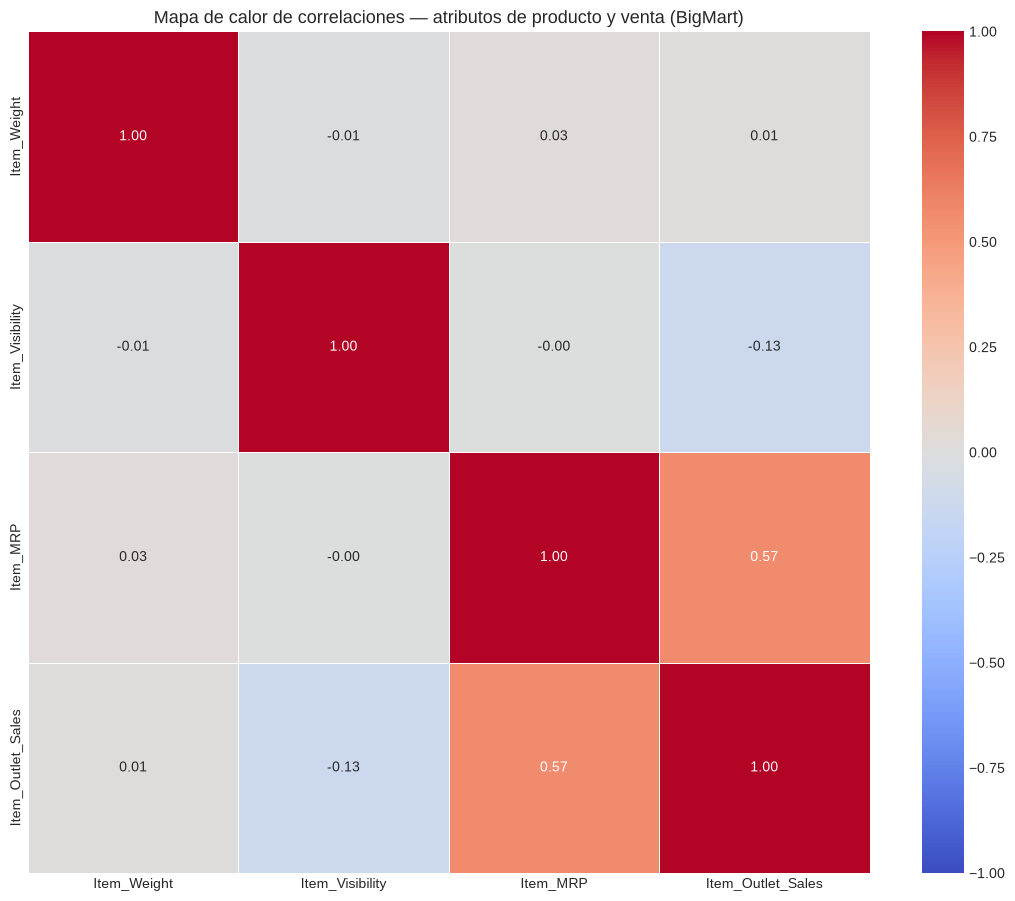

Los cuatro parametros que importan:
  center=0    -> pone el color neutro en el cero. Sin eso, un r de 0,3 puede verse tan
                 intenso como uno de 0,9, y el grafico miente sin avisar.
  vmin/vmax   -> fija la escala al rango real de r, para que dos mapas distintos puedan
                 compararse entre si.
  annot=True  -> escribe el numero en la celda. Sin esto es decoracion.
  cmap        -> azul para negativo, rojo para positivo.


In [27]:
plt.figure(figsize=(11, 9))
sns.heatmap(matriz,
            annot=True,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Mapa de calor de correlaciones — atributos de producto y venta (BigMart)', fontsize=13)
plt.tight_layout()
plt.show()

print('Los cuatro parametros que importan:')
print("  center=0    -> pone el color neutro en el cero. Sin eso, un r de 0,3 puede verse tan")
print('                 intenso como uno de 0,9, y el grafico miente sin avisar.')
print('  vmin/vmax   -> fija la escala al rango real de r, para que dos mapas distintos puedan')
print('                 compararse entre si.')
print('  annot=True  -> escribe el numero en la celda. Sin esto es decoracion.')
print('  cmap        -> azul para negativo, rojo para positivo.')

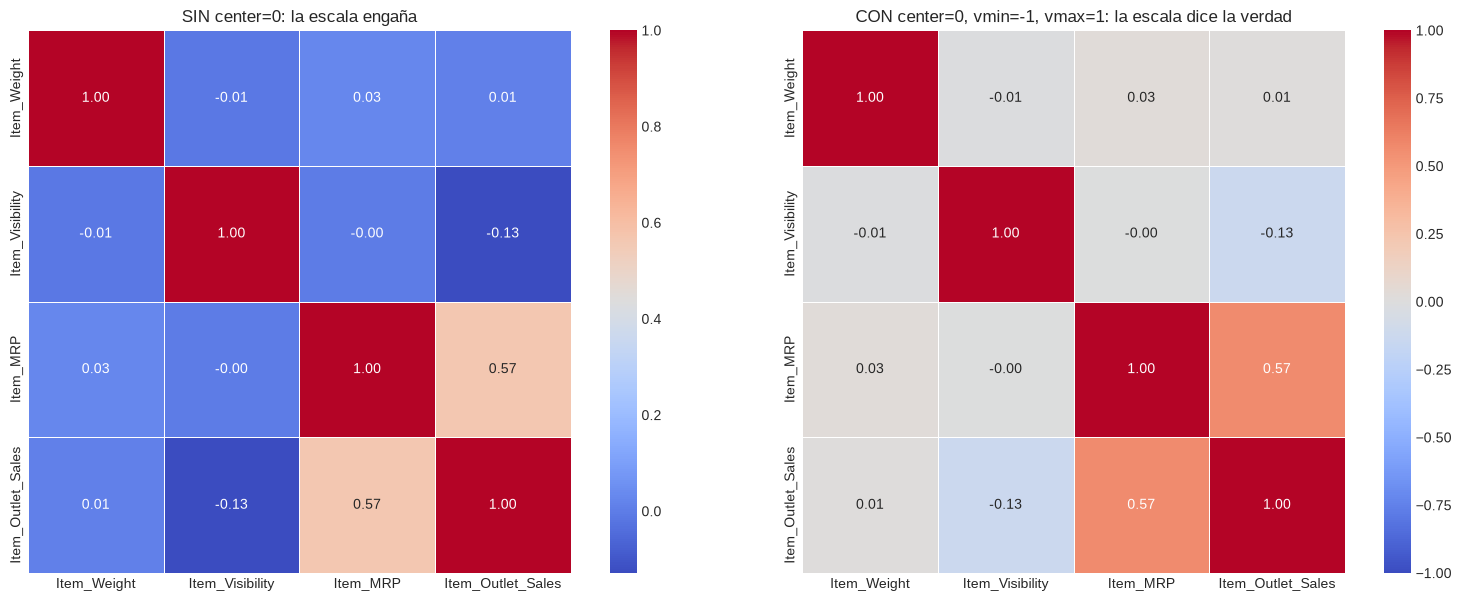

In [28]:
# El contraste que demuestra por que center=0 no es cosmetico: la version sin center=0 reparte
# toda la escala entre el minimo y el maximo de ESTA matriz, y como no hay correlaciones negativas
# el color neutro deja de estar en el cero.
fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5, ax=ejes[0], cbar=True)
ejes[0].set_title('SIN center=0: la escala engaña')

sns.heatmap(matriz, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            fmt='.2f', square=True, linewidths=0.5, ax=ejes[1], cbar=True)
ejes[1].set_title('CON center=0, vmin=-1, vmax=1: la escala dice la verdad')

plt.tight_layout()
plt.show()

### Paso 3 y 4 del marco · Cuantificar e interrogar la relación más fuerte

La más fuerte es `Item_MRP` contra `Item_Outlet_Sales`. Y hay que decir tres cosas: qué mide cada
variable, si el mecanismo tiene sentido, y qué confusora podría ir detrás.

In [29]:
print('=' * 78)
print('TRAMO · 10b · La correlacion mas fuerte, explicada')
print('=' * 78)


def fuerza_de(r):
    if abs(r) > 0.7:
        return 'FUERTE'
    if abs(r) > 0.3:
        return 'MODERADA'
    return 'DEBIL'


COL_A, COL_B = 'Item_MRP', 'Item_Outlet_Sales'

for a, b in [(COL_A, COL_B),
             ('Item_Visibility', COL_B),
             ('Item_Weight', COL_B)]:
    r = df[a].corr(df[b])
    direccion = 'positiva' if r > 0 else 'negativa'
    filas = (df[a].notna() & df[b].notna()).sum()
    print(f'{a:<20} vs {b:<20} r = {r:>7.3f}   n = {filas:>6,}   '
          f'correlacion {fuerza_de(r)} {direccion}')
print()

r_fuerte = df[COL_A].corr(df[COL_B])
print(f'LA MAS FUERTE: {COL_A} contra {COL_B}, r = {r_fuerte:.3f}, '
      f'correlacion {fuerza_de(r_fuerte)} positiva.')
print()
print('Que mide cada una:')
print('  Item_MRP         -> precio de lista del producto. Es lo que el fabricante pide, no lo que')
print('                      se cobra: no tiene ningun descuento aplicado.')
print('  Item_Outlet_Sales-> venta de ese producto en esa tienda. Si el precio bajista es efectivo')
print('                      y las ventas suben, eso es margen.')
print()
print('Interrogarla con las cuatro preguntas del paso 4:')
print()
print('  1 · ¿Tiene sentido logico? Si. El mecanismo es economico y se cuenta paso a paso: un')
print('      producto mas caro ocupa mas valor por unidad de espacio, y a igualdad de condicion')
print('      mueve mas pesos en la caja. Es el unico par del archivo donde el mecanismo es contable.')
print()
print('  2 · ¿El orden temporal funciona? Si. El precio de lista se fija antes de la venta.')
print()
print('  3 · ¿Puede haber una tercera variable escondida? Si, y hay dos candidatas concretas:')
print('      Item_Type, porque cada familia de producto tiene su propio nivel de precios; y')
print('      Outlet_Type, porque las Grocery Store venden una fracción. El paso 5 las separa.')
print()
print('  4 · ¿Podria ser espuria? Poco. El mecanismo es directo y no salió de rastrillar mil pares.')
print('      Aqui solo hay cuatro variables numericas, y el riesgo real de este archivo es otro,')
print('      que se comprueba en el tramo 12.')

TRAMO · 10b · La correlacion mas fuerte, explicada
Item_MRP             vs Item_Outlet_Sales    r =   0.568   n =  8,523   correlacion MODERADA positiva
Item_Visibility      vs Item_Outlet_Sales    r =  -0.129   n =  8,523   correlacion DEBIL negativa
Item_Weight          vs Item_Outlet_Sales    r =   0.010   n =  8,523   correlacion DEBIL positiva

LA MAS FUERTE: Item_MRP contra Item_Outlet_Sales, r = 0.568, correlacion MODERADA positiva.

Que mide cada una:
  Item_MRP         -> precio de lista del producto. Es lo que el fabricante pide, no lo que
                      se cobra: no tiene ningun descuento aplicado.
  Item_Outlet_Sales-> venta de ese producto en esa tienda. Si el precio bajista es efectivo
                      y las ventas suben, eso es margen.

Interrogarla con las cuatro preguntas del paso 4:

  1 · ¿Tiene sentido logico? Si. El mecanismo es economico y se cuenta paso a paso: un
      producto mas caro ocupa mas valor por unidad de espacio, y a igualdad de condicion

### Paso 2 del marco · Graficar antes de calcular

`r` mide relación **lineal** y nada más. Cuatro cosas que no ve: una curva perfecta, un punto
extremo, una mezcla de poblaciones, y el hecho de que con pocos datos no dice nada. Por eso el
gráfico va antes del número.

Scatter sobre una muestra de 6,000 filas de las 8,523 del archivo
(random_state=42, la misma muestra en cada corrida).



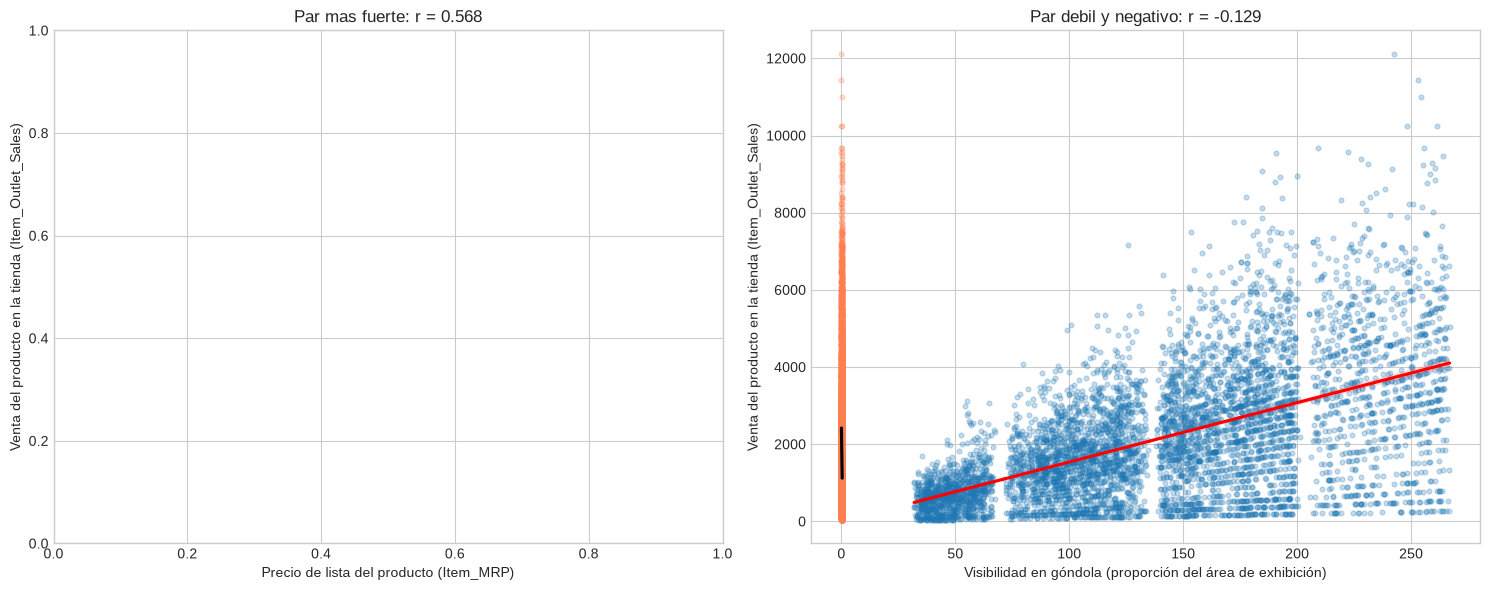

In [30]:
# Se dibuja sobre una muestra para que la nube se lea; el tamano se declara en la salida.
muestra = df.sample(6000, random_state=SEMILLA)
print(f'Scatter sobre una muestra de {len(muestra):,} filas de las {len(df):,} del archivo')
print(f'(random_state={SEMILLA}, la misma muestra en cada corrida).')
print()

fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

sns.regplot(x=COL_A, y=COL_B, data=muestra,
            scatter_kws={'alpha': 0.25, 's': 12},
            line_kws={'color': 'red'})
ejes[0].set_xlabel('Precio de lista del producto (Item_MRP)')
ejes[0].set_ylabel('Venta del producto en la tienda (Item_Outlet_Sales)')
ejes[0].set_title(f'Par mas fuerte: r = {r_fuerte:.3f}')

sns.regplot(x='Item_Visibility', y=COL_B, data=muestra,
            scatter_kws={'alpha': 0.25, 's': 12, 'color': 'coral'},
            line_kws={'color': 'black'})
ejes[1].set_xlabel('Visibilidad en góndola (proporción del área de exhibición)')
ejes[1].set_ylabel('Venta del producto en la tienda (Item_Outlet_Sales)')
ejes[1].set_title(f'Par debil y negativo: r = {df["Item_Visibility"].corr(df[COL_B]):.3f}')

plt.tight_layout()
plt.show()

In [31]:
print('=' * 78)
print('TRAMO · 10c · Mirar la nube despues del numero')
print('=' * 78)

print('Las cinco preguntas que se le hacen a un scatter:')
print()
print('  1 · ¿Hay tendencia? Si, en los dos pares. Una recta con pendiente positiva en el grafico')
print('      de la izquierda y casi horizontal en el de la derecha.')
print()
print('  2 · ¿Que forma tiene? En el par fuerte la nube es un cono que se abre hacia arriba: a')
print('      mayor precio, mayor dispersion. Un cono NO es una recta, y r no lo penaliza.')
print()
print('  3 · ¿Cuanto ruido hay alrededor? Mucho en el par fuerte. La relacion es real pero lejana:')
print('      el precio solo explica una parte.')
print()
print('  4 · ¿Hay puntos sueltos muy lejos? Si. El cono de la derecha lo abren las Grocery Store,')
print('      las dos unicas con la venta baja. No es ruido: es un grupo.')
print()
print('  5 · ¿Hay grupos? Si, y es el punto. El grafico de la derecha tiene una nube baja separada')
print('      del resto. Un r de -0,13 resume las dos poblaciones a la vez y no dice que existen.')
print()

# La mezcla de poblaciones, cuantificada: el mismo r con y sin el grupo que rompe la nube.
sin_grocery = df[df['Outlet_Type'] != 'Grocery Store']
r_con_todas = df['Item_Visibility'].corr(df[COL_B])
r_sin_grocery = sin_grocery['Item_Visibility'].corr(sin_grocery[COL_B])

print('Cuantificar esa separacion:')
print(f'  r(visibilidad, venta) con las {len(df):,} filas            : {r_con_todas:.3f}')
print(f'  r(visibilidad, venta) sin las {len(sin_grocery):,} Grocery Store : {r_sin_grocery:.3f}')
print()
print('El numero se mueve poco, pero la lectura cambia del todo: el -0,13 no era "la gondola esta')
print('contra las ventas". Era "las tiendas que no son supermercado venden muy poco, y la gondola')
print('se usa mas en las tiendas grandes".')

TRAMO · 10c · Mirar la nube despues del numero
Las cinco preguntas que se le hacen a un scatter:

  1 · ¿Hay tendencia? Si, en los dos pares. Una recta con pendiente positiva en el grafico
      de la izquierda y casi horizontal en el de la derecha.

  2 · ¿Que forma tiene? En el par fuerte la nube es un cono que se abre hacia arriba: a
      mayor precio, mayor dispersion. Un cono NO es una recta, y r no lo penaliza.

  3 · ¿Cuanto ruido hay alrededor? Mucho en el par fuerte. La relacion es real pero lejana:
      el precio solo explica una parte.

  4 · ¿Hay puntos sueltos muy lejos? Si. El cono de la derecha lo abren las Grocery Store,
      las dos unicas con la venta baja. No es ruido: es un grupo.

  5 · ¿Hay grupos? Si, y es el punto. El grafico de la derecha tiene una nube baja separada
      del resto. Un r de -0,13 resume las dos poblaciones a la vez y no dice que existen.

Cuantificar esa separacion:
  r(visibilidad, venta) con las 8,523 filas            : -0.129
  r(visibil

### Paso 5 del marco · Segmentar: ¿la relación se sostiene dentro de cada categoría de producto?

Este es el chequeo de Simpson aplicado a un par numérico, y es el que responde la segunda mitad de
**P3**. Se recalcula `r` dentro de cada `Item_Type` y dentro de cada nivel de ciudad, y se compara con
el global.

El entregable es el **chequeo**, no la paradoja. Si la relación se sostiene, ese es un resultado
completo: que sobreviva la hace más creíble, no menos. Forzar los datos hasta que aparezca una
paradoja es justamente lo que esta clase enseña a no hacer.

In [32]:
print('=' * 78)
print('TRAMO · 10d · Chequeo de segmentacion sobre el par mas fuerte')
print('=' * 78)

print(f'r GLOBAL entre {COL_A} y {COL_B}: {r_fuerte:.3f}   n = {len(df):,}')
print()
print('r DENTRO de cada Item_Type (solo grupos con mas de 30 filas):')
print('-' * 62)

resultados_categoria = []
for categoria in sorted(df['Item_Type'].unique()):
    grupo = df[df['Item_Type'] == categoria]
    if len(grupo) > 30:
        resultados_categoria.append((categoria, grupo[COL_A].corr(grupo[COL_B]), len(grupo)))

for categoria, r_grupo, n in sorted(resultados_categoria, key=lambda t: -t[1]):
    marca = '  <-- ojo' if abs(r_grupo - r_fuerte) > 0.3 else ''
    print(f'{categoria:<24} r = {r_grupo:6.3f}   n = {n:5,}{marca}')
print('-' * 62)

rs = [r for _, r, _ in resultados_categoria]
positivos = sum(1 for r in rs if r > 0)
print(f'Grupos evaluados: {len(rs)}   Con r positivo: {positivos}')
print(f'r minimo dentro de un grupo: {min(rs):.3f}')
print(f'r maximo dentro de un grupo: {max(rs):.3f}')
print()
print('El signo NO se invierte en ningun grupo, y la fuerza se mueve poco. La relacion no es un')
print('artefacto de la mezcla de categorias: existe dentro de cada familia de producto.')

TRAMO · 10d · Chequeo de segmentacion sobre el par mas fuerte
r GLOBAL entre Item_MRP y Item_Outlet_Sales: 0.568   n = 8,523

r DENTRO de cada Item_Type (solo grupos con mas de 30 filas):
--------------------------------------------------------------


Frozen Foods             r =  0.635   n =   856
Hard Drinks              r =  0.618   n =   214
Baking Goods             r =  0.593   n =   648
Dairy                    r =  0.583   n =   682
Canned                   r =  0.581   n =   649
Starchy Foods            r =  0.577   n =   148
Health and Hygiene       r =  0.572   n =   520
Fruits and Vegetables    r =  0.566   n = 1,232
Others                   r =  0.566   n =   169
Breads                   r =  0.564   n =   251
Soft Drinks              r =  0.560   n =   445
Seafood                  r =  0.553   n =    64
Meat                     r =  0.542   n =   425
Breakfast                r =  0.534   n =   110
Snack Foods              r =  0.519   n = 1,200
Household                r =  0.517   n =   910
--------------------------------------------------------------
Grupos evaluados: 16   Con r positivo: 16
r minimo dentro de un grupo: 0.517
r maximo dentro de un grupo: 0.635

El signo NO se invierte en ningun grupo, y la fuerza se 

In [33]:
print('=' * 78)
print('TRAMO · 10e · Y ahora por nivel de ciudad, que es donde si se leen las confusoras')
print('=' * 78)

print(f'r GLOBAL entre {COL_A} y {COL_B}: {r_fuerte:.3f}')
print()
print('r DENTRO de cada Outlet_Location_Type:')
print('-' * 52)

for nivel in sorted(df['Outlet_Location_Type'].unique()):
    grupo = df[df['Outlet_Location_Type'] == nivel]
    print(f'{nivel:<10} r = {grupo[COL_A].corr(grupo[COL_B]):6.3f}   n = {len(grupo):5,}')
print('-' * 52)
print()

print('r GLOBAL entre Item_Visibility y Item_Outlet_Sales: '
      f'{df["Item_Visibility"].corr(df[COL_B]):.3f}')
print('r DENTRO de cada Outlet_Location_Type:')
print('-' * 52)

for nivel in sorted(df['Outlet_Location_Type'].unique()):
    grupo = df[df['Outlet_Location_Type'] == nivel]
    print(f'{nivel:<10} r = {grupo["Item_Visibility"].corr(grupo[COL_B]):6.3f}   n = {len(grupo):5,}')
print('-' * 52)
print()
print('Aqui si se ve algo: en Tier 2 la relacion entre visibilidad y venta es prácticamente nula,')
print('mientras que en Tier 1 y Tier 3 es debil y negativa. El numero global de -0,13 es un promedio')
print('de tres cosas distintas, y por si solo no es un hallazgo.')

TRAMO · 10e · Y ahora por nivel de ciudad, que es donde si se leen las confusoras
r GLOBAL entre Item_MRP y Item_Outlet_Sales: 0.568

r DENTRO de cada Outlet_Location_Type:
----------------------------------------------------
Tier 1     r =  0.530   n = 2,388
Tier 2     r =  0.682   n = 2,785
Tier 3     r =  0.529   n = 3,350
----------------------------------------------------

r GLOBAL entre Item_Visibility y Item_Outlet_Sales: -0.129
r DENTRO de cada Outlet_Location_Type:
----------------------------------------------------
Tier 1     r = -0.185   n = 2,388
Tier 2     r = -0.024   n = 2,785
Tier 3     r = -0.140   n = 3,350
----------------------------------------------------

Aqui si se ve algo: en Tier 2 la relacion entre visibilidad y venta es prácticamente nula,
mientras que en Tier 1 y Tier 3 es debil y negativa. El numero global de -0,13 es un promedio
de tres cosas distintas, y por si solo no es un hallazgo.


## 11. Marco bivariado · Categórica contra numérica, P4

Acá cambia el gráfico y cambia la métrica: no hay `r`, hay **diferencia de medias**, y siempre
acompañada del **conteo**, porque una media sin su conteo no se puede interpretar.

**Respuesta a P4** — qué diferencias entre tipos de tienda y entre niveles de ciudad sobreviven al
partir el archivo por grupo.

La pregunta con consecuencias, y la que hay que responder con honestidad: *las Grocery Store venden
muchísimo menos. ¿Es el tipo de tienda, o es que las Grocery Store son tiendas de barrio?*

In [34]:
print('=' * 78)
print('TRAMO · 11 · Categórica contra numérica')
print('=' * 78)

print('Las medias por tipo de tienda, CON SU CONTEO:')
por_tipo = (df.groupby('Outlet_Type')[COL_B]
              .agg(promedio='mean', mediana='median', filas='size')
              .sort_values('promedio', ascending=False))
print(por_tipo.round(2).to_string())
print()

print('Las medias por nivel de ciudad, CON SU CONTEO:')
por_nivel = (df.groupby('Outlet_Location_Type')[COL_B]
               .agg(promedio='mean', mediana='median', filas='size')
               .sort_values('promedio', ascending=False))
print(por_nivel.round(2).to_string())
print()

print('Y por tamaño declarado, CON SU CONTEO:')
por_tamano = (df.groupby('Outlet_Size')[COL_B]
                .agg(promedio='mean', mediana='median', filas='size')
                .sort_values('promedio', ascending=False))
print(por_tamano.round(2).to_string())
print()
print('La fila "Sin dato" son las ', f'{int(por_tamano.loc["Sin dato", "filas"]):,}',
      'filas Supermarket Type1 sin tamaño declarado.')
print('Se deja a la vista a proposito: es el costo de no rellenar, y esconderia el hueco.')

TRAMO · 11 · Categórica contra numérica
Las medias por tipo de tienda, CON SU CONTEO:


                   promedio  mediana  filas
Outlet_Type                                
Supermarket Type3   3694.04  3364.95    935
Supermarket Type1   2316.18  1990.74   5577
Supermarket Type2   1995.50  1655.18    928
Grocery Store        339.83   257.00   1083

Las medias por nivel de ciudad, CON SU CONTEO:
                      promedio  mediana  filas
Outlet_Location_Type                          
Tier 2                 2323.99  2004.06   2785
Tier 3                 2279.63  1812.31   3350
Tier 1                 1876.91  1487.40   2388

Y por tamaño declarado, CON SU CONTEO:
             promedio  mediana  filas
Outlet_Size                          
Medium        2681.60  2251.07   2793
High          2299.00  2050.66    932
Sin dato      2266.41  1946.80   1855
Small         1615.55  1090.58   2943

La fila "Sin dato" son las  1,855 filas Supermarket Type1 sin tamaño declarado.
Se deja a la vista a proposito: es el costo de no rellenar, y esconderia el hueco.


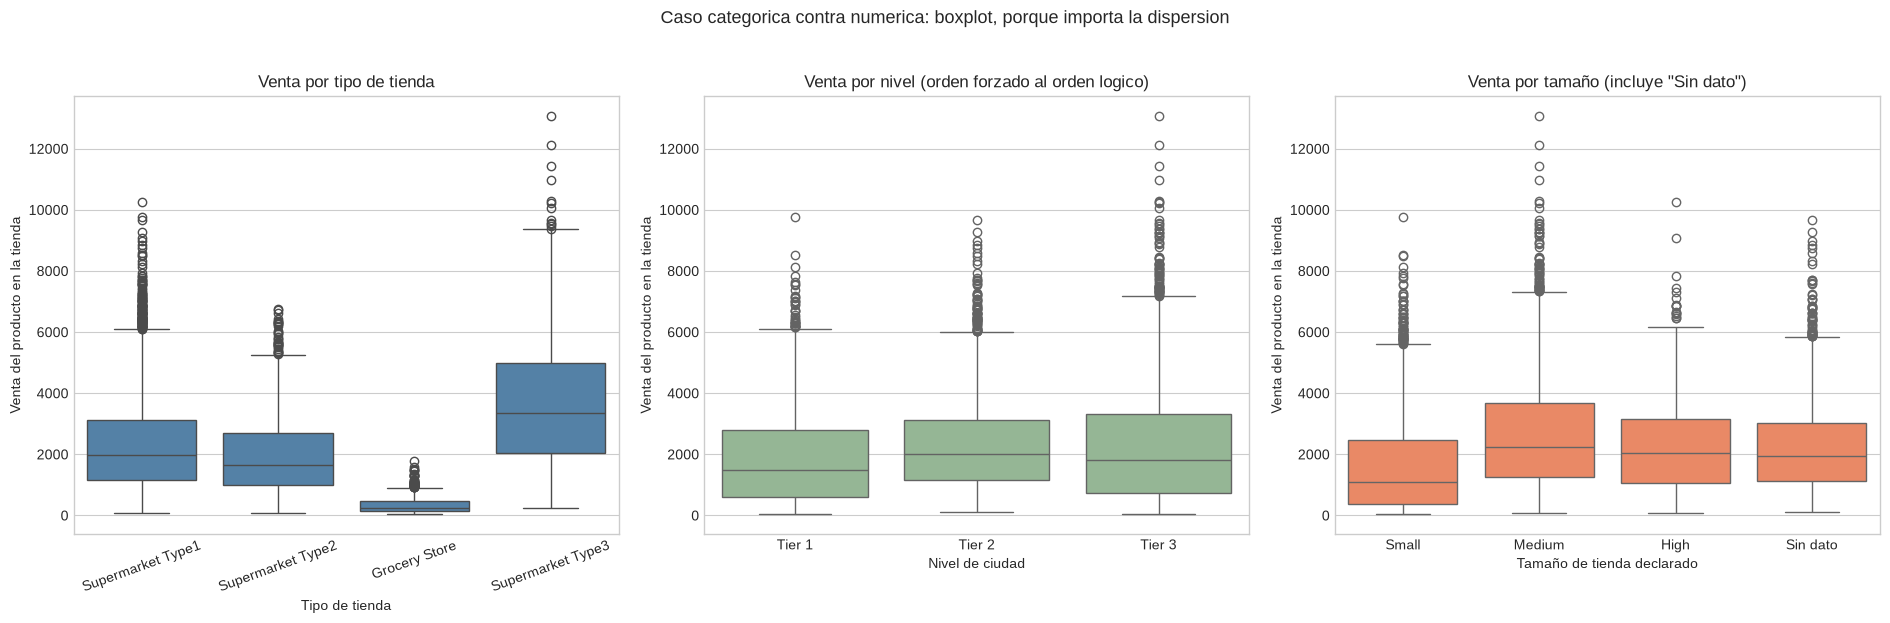

Por que boxplot y no barras de medias:
  Barras de medias Cuando lo unico que importa es comparar niveles. Aqui importa tambien CUANTO
  se dispersan las ventas dentro de cada tipo: dos tiendas con la misma media y una con las
  ventas concentradas y otra con una cola larga cuentan historias distintas, y la barra las
  esconde. Ademas aqui las cajas se veian separadas a simple vista: eso ya es informacion.


In [35]:
fig, ejes = plt.subplots(1, 3, figsize=(19, 6))

sns.boxplot(x='Outlet_Type', y=COL_B, data=df, ax=ejes[0], color='steelblue')
ejes[0].set_xlabel('Tipo de tienda')
ejes[0].set_ylabel('Venta del producto en la tienda')
ejes[0].set_title('Venta por tipo de tienda')
ejes[0].tick_params(axis='x', rotation=20)

sns.boxplot(x='Outlet_Location_Type', y=COL_B, data=df, ax=ejes[1],
            order=['Tier 1', 'Tier 2', 'Tier 3'], color='darkseagreen')
ejes[1].set_xlabel('Nivel de ciudad')
ejes[1].set_ylabel('Venta del producto en la tienda')
ejes[1].set_title('Venta por nivel (orden forzado al orden logico)')

sns.boxplot(x='Outlet_Size', y=COL_B, data=df, ax=ejes[2],
            order=['Small', 'Medium', 'High', 'Sin dato'], color='coral')
ejes[2].set_xlabel('Tamaño de tienda declarado')
ejes[2].set_ylabel('Venta del producto en la tienda')
ejes[2].set_title('Venta por tamaño (incluye "Sin dato")')

plt.suptitle('Caso categorica contra numerica: boxplot, porque importa la dispersion',
             y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

print('Por que boxplot y no barras de medias:')
print('  Barras de medias Cuando lo unico que importa es comparar niveles. Aqui importa tambien CUANTO')
print('  se dispersan las ventas dentro de cada tipo: dos tiendas con la misma media y una con las')
print('  ventas concentradas y otra con una cola larga cuentan historias distintas, y la barra las')
print('  esconde. Ademas aqui las cajas se veian separadas a simple vista: eso ya es informacion.')

In [36]:
print('=' * 78)
print('TRAMO · 11b · El chequeo: ¿sobrevive la ventaja al partir por grupo?')
print('=' * 78)

print('1 · EL RESULTADO GLOBAL')
print()
print('   Las Grocery Store venden mucho menos que el resto. Esa es la conclusion obvia, y aqui')
print('   se demuestra con numeros y con su conteo:')
print()
mejor_otro = por_tipo.drop('Grocery Store')['promedio'].max()
peor = por_tipo['promedio'].min()
print(f'     Peor tipo de tienda     : Grocery Store, {peor:,.2f} '
      f'({int(por_tipo.loc["Grocery Store", "filas"]):,} filas)')
print(f'     Mejor tipo de tienda    : {por_tipo["promedio"].idxmax()}, '
      f'{por_tipo["promedio"].max():,.2f} '
      f'({int(por_tipo.loc[por_tipo["promedio"].idxmax(), "filas"]):,} filas)')
print(f'     La diferencia es de {mejor_otro / peor:,.1f} veces')
print()
print('2 · LA PREGUNTA DE FONDO')
print()
print('   ¿Es el tipo de tienda, o es que las Grocery Store de este archivo son tiendas de barrio?')
print('   Las dos cosas pueden ser verdad a la vez, y si solo se reporta el resultado global se')
print('   presenta como causa lo que podria ser composicion.')
print()

print('3 · LA TABLA CRUZADA: tipo de tienda contra nivel de ciudad')
print()
cruzada = pd.crosstab(df['Outlet_Type'], df['Outlet_Location_Type'])
print(cruzada.to_string())
print()
print('4 · LOS TAMANOS DE CADA CELDA, porque sin esto la tabla se lee a medias')
print()
print('Esto es lo que revela la estructura:')
print()
print('  - Las Grocery Store SOLO existen en Tier 1 y Tier 3. Nunca en Tier 2.')
print('  - Supermarket Type2 y Type3 SOLO existen en Tier 3.')
print('  - Supermarket Type1 es el unico que aparece en los tres niveles.')
print()
print('Es decir: tipo de tienda y nivel de ciudad no son variables independientes. Estan atadas.')
print('Eso es exactamente lo que produce una paradoja de Simpson: una relacion en el conjunto que')
print('se explica por la composicion de los grupos.')

TRAMO · 11b · El chequeo: ¿sobrevive la ventaja al partir por grupo?
1 · EL RESULTADO GLOBAL

   Las Grocery Store venden mucho menos que el resto. Esa es la conclusion obvia, y aqui
   se demuestra con numeros y con su conteo:

     Peor tipo de tienda     : Grocery Store, 339.83 (1,083 filas)
     Mejor tipo de tienda    : Supermarket Type3, 3,694.04 (935 filas)
     La diferencia es de 10.9 veces

2 · LA PREGUNTA DE FONDO

   ¿Es el tipo de tienda, o es que las Grocery Store de este archivo son tiendas de barrio?
   Las dos cosas pueden ser verdad a la vez, y si solo se reporta el resultado global se
   presenta como causa lo que podria ser composicion.

3 · LA TABLA CRUZADA: tipo de tienda contra nivel de ciudad

Outlet_Location_Type  Tier 1  Tier 2  Tier 3
Outlet_Type                                 
Grocery Store            528       0     555
Supermarket Type1       1860    2785     932
Supermarket Type2          0       0     928
Supermarket Type3          0       0     935

4 

In [37]:
print('=' * 78)
print('TRAMO · 11c · La comparacion, celda por celda')
print('=' * 78)

print('5 · LA COMPARACION: los dos tipos que se comparan, nivel por nivel, con su diferencia')
print()

comparacion = []
for nivel in ['Tier 1', 'Tier 2', 'Tier 3']:
    grupo = df[df['Outlet_Location_Type'] == nivel]
    oficial = grupo[grupo['Outlet_Type'] == 'Supermarket Type1']['Item_Outlet_Sales']
    grocery = grupo[grupo['Outlet_Type'] == 'Grocery Store']['Item_Outlet_Sales']
    if len(oficial) and len(grocery):
        fila = {
            'nivel': nivel,
            'supermarket_type1': oficial.mean(),
            'grocery_store': grocery.mean(),
            'n_type1': len(oficial),
            'n_grocery': len(grocery),
        }
        fila['diferencia'] = fila['supermarket_type1'] - fila['grocery_store']
        fila['razon'] = fila['supermarket_type1'] / fila['grocery_store']
        comparacion.append(fila)

tabla_comparacion = pd.DataFrame(comparacion).set_index('nivel')
print(tabla_comparacion.round(2).to_string())
print()

for nivel, fila in tabla_comparacion.iterrows():
    print(f'{nivel}: el supermercado promedia {fila["razon"]:,.1f} veces lo de la Grocery Store,')
    print(f'  con {int(fila["n_type1"]):,} filas de un lado y {int(fila["n_grocery"]):,} del otro.')
print()

print('6 · EL VEREDICTO, TAL COMO SALIO')
print()
print('NO aparece paradoja de Simpson.')
print()
print('En los dos niveles donde hay Grocery Store, la diferencia se mantiene y es enorme: el')
print('supermercado vende varias veces mas. El signo no se invierte en ninguna celda, y la diferencia')
print('no se acerca a cero en ninguna. Una paradoja es un caso en que el efecto global cambia de')
print('signo al partir; aqui el efecto global y los efectos por celda dicen lo mismo.')
print()
print('Eso NO debilita la conclusion: la hace mas creible. Que una relacion sobreviva a partirla por')
print('grupos es lo que se_busca, no lo contrario. El entregable de este bloque es el chequeo.')
print()
print('Y ademas hay una honestidad que obliga: la relacion se sostiene entre lo que SÍ se puede')
print('comparar. En Tier 2 no hay Grocery Store, asi que esa celda no existe y no se puede afirmar')
print('nada del tipo de tienda alli. Un grupo que no esta en la tabla no es un grupo con cero.')

TRAMO · 11c · La comparacion, celda por celda
5 · LA COMPARACION: los dos tipos que se comparan, nivel por nivel, con su diferencia

        supermarket_type1  grocery_store  n_type1  n_grocery  diferencia  razon
nivel                                                                          
Tier 1             2313.1         340.33     1860        528     1972.77   6.80
Tier 3             2299.0         339.35      932        555     1959.64   6.77

Tier 1: el supermercado promedia 6.8 veces lo de la Grocery Store,
  con 1,860 filas de un lado y 528 del otro.
Tier 3: el supermercado promedia 6.8 veces lo de la Grocery Store,
  con 932 filas de un lado y 555 del otro.

6 · EL VEREDICTO, TAL COMO SALIO

NO aparece paradoja de Simpson.

En los dos niveles donde hay Grocery Store, la diferencia se mantiene y es enorme: el
supermercado vende varias veces mas. El signo no se invierte en ninguna celda, y la diferencia
no se acerca a cero en ninguna. Una paradoja es un caso en que el efecto gl

## 12. El límite del archivo · Diez tiendas

Este es el hallazgo más importante del cuaderno, y no aparece en ninguna de las correlaciones.

Hay **diez tiendas**. Cada una tiene un tamaño, un tipo, un nivel y un año. Se comprueba si esas diez
combinaciones son distintas: si lo son, entonces las cuatro variables de tienda son **la misma
variable con cuatro nombres**, y cualquier correlación entre ellas no es un hallazgo sino una
consecuencia de cómo se armó el archivo.

La regla del semestre con pocos datos es directa: con menos de diez observaciones `r` es casi ruido.
Este archivo tiene exactamente diez.

In [38]:
print('=' * 78)
print('TRAMO · 12 · El límite del archivo: diez tiendas')
print('=' * 78)

atributos_tienda = ['Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type',
                    'Outlet_Establishment_Year']

combinaciones = df[atributos_tienda].drop_duplicates()
print(f'Tiendas distintas                        : {df["Outlet_Identifier"].nunique()}')
print(f'Combinaciones distintas de sus 4 atributos: {len(combinaciones)}')
print()
print('Es una correspondencia de uno a uno. Cada tienda tiene su propia combinacion unica de tipo,')
print('tamano, nivel y anio de fundacion. Eso significa que las cuatro variables de tienda son')
print('ETIQUETAS DE LA MISMA COSA: saber el tipo de tienda ES saber que tienda es.')
print()

ficha = (df.groupby('Outlet_Identifier')
           .agg(tipo=('Outlet_Type', 'first'),
                tamano=('Outlet_Size', 'first'),
                nivel=('Outlet_Location_Type', 'first'),
                anio=('Outlet_Establishment_Year', 'first'),
                filas=('Item_Type', 'size'),
                venta_promedio=('Item_Outlet_Sales', 'mean'),
                venta_total=('Item_Outlet_Sales', 'sum'))
           .sort_values('venta_promedio', ascending=False))
print('Las diez tiendas, con todo lo que se sabe de cada una:')
print(ficha.round(2).to_string())
print()

total_general = df[COL_B].sum()
participacion = (ficha['venta_total'] / total_general * 100).sort_values(ascending=False)
print('Participacion de cada tienda en la venta total del archivo:')
print(participacion.round(2).to_string())
print()
print(f'Las dos Grocery Store juntas se llevan el '
      f'{participacion[["OUT010", "OUT019"]].sum():.2f}% de la venta total.')
print(f'Las dos mayores, el {participacion.head(2).sum():.2f}%.')

TRAMO · 12 · El límite del archivo: diez tiendas
Tiendas distintas                        : 10
Combinaciones distintas de sus 4 atributos: 10

Es una correspondencia de uno a uno. Cada tienda tiene su propia combinacion unica de tipo,
tamano, nivel y anio de fundacion. Eso significa que las cuatro variables de tienda son
ETIQUETAS DE LA MISMA COSA: saber el tipo de tienda ES saber que tienda es.



Las diez tiendas, con todo lo que se sabe de cada una:
                                tipo    tamano   nivel  anio  filas  venta_promedio  venta_total
Outlet_Identifier                                                                               
OUT027             Supermarket Type3    Medium  Tier 3  1985    935         3694.04   3453926.05
OUT035             Supermarket Type1     Small  Tier 2  2004    930         2438.84   2268122.94
OUT049             Supermarket Type1    Medium  Tier 1  1999    930         2348.35   2183969.81
OUT017             Supermarket Type1  Sin dato  Tier 2  2007    926         2340.68   2167465.29
OUT013             Supermarket Type1      High  Tier 3  1987    932         2299.00   2142663.58
OUT046             Supermarket Type1     Small  Tier 1  1997    930         2277.84   2118395.17
OUT045             Supermarket Type1  Sin dato  Tier 2  2002    929         2192.38   2036725.48
OUT018             Supermarket Type2    Medium  Tier 3  2009    928     

In [39]:
print('=' * 78)
print('TRAMO · 12b · Correlaciones calculadas sobre DIEZ observaciones')
print('=' * 78)

ORDEN_TAMANO = {'Small': 1, 'Medium': 2, 'High': 3}
nivel_tienda = ficha.copy()
nivel_tienda['tamano_ordinal'] = nivel_tienda['tamano'].map(ORDEN_TAMANO)
nivel_tienda['antiguedad'] = 2013 - nivel_tienda['anio']

print('Para poder correlelacionar el tamaño hay que darle un orden. Small < Medium < High.')
print('Es un supuesto del analista, y por eso se declara: el archivo no dice que High sea mayor que')
print('Medium en ninguna unidad, solo viene en ese orden.')
print()

numericas_tienda = ['tamano_ordinal', 'antiguedad', 'venta_promedio']
print('Matriz de correlacion a nivel de TIENDA:')
print(nivel_tienda[numericas_tienda].corr().round(3).to_string())
print()
print(f'n = {len(nivel_tienda)} observaciones')
print()
print('COMO SE LEE ESTA TABLA, Y POR QUE NO ES UN HALLAZGO:')
print()
print('  Con diez observaciones, un r de 0,37 no es una relacion: es ruido con signo. La regla del')
print('  semestre es que con menos de diez datos r no significa gran cosa, y este archivo esta')
print('  justo en el limite con exactamente diez tiendas.')
print()
print('  Peor: el tamaño y la antiguedad se anticorrelacionan (r = -0,199) porque hay tres tiendas')
print('  de 1985, 1987 y 1998 y ninguna de 1990, 1995 o 2000. Eso no es una tendencia del retail,')
print('  es que las fechas se elegieron asi.')
print()
print('  Y la mas fuerte de todas, r = 0,367 entre tamaño y venta, se explica sin ninguna teoria:')
print('  la tienda mas grande (OUT027) es una Supermarket Type3 en Tier 3. "Tamaño" aqui es un')
print('  nombre para "OUT027", que es un nombre para "la tienda que mas vende".')

TRAMO · 12b · Correlaciones calculadas sobre DIEZ observaciones
Para poder correlelacionar el tamaño hay que darle un orden. Small < Medium < High.
Es un supuesto del analista, y por eso se declara: el archivo no dice que High sea mayor que
Medium en ninguna unidad, solo viene en ese orden.

Matriz de correlacion a nivel de TIENDA:
                tamano_ordinal  antiguedad  venta_promedio
tamano_ordinal           1.000       0.224           0.478
antiguedad               0.224       1.000          -0.037
venta_promedio           0.478      -0.037           1.000

n = 10 observaciones

COMO SE LEE ESTA TABLA, Y POR QUE NO ES UN HALLAZGO:

  Con diez observaciones, un r de 0,37 no es una relacion: es ruido con signo. La regla del
  semestre es que con menos de diez datos r no significa gran cosa, y este archivo esta
  justo en el limite con exactamente diez tiendas.

  Peor: el tamaño y la antiguedad se anticorrelacionan (r = -0,199) porque hay tres tiendas
  de 1985, 1987 y 1998 y ning

La conclusión del tramo, y es la que gobierna todo lo que sigue: **en este archivo, cualquier
comparación entre tiendas es una comparación entre diez tiendas**. No se puede separar el efecto del
tipo, del tamaño, del nivel o del año, porque en este archivo esos cuatro atributos se mueven juntos.
Lo que sí se puede es describirlos, y comparar productos **dentro** de una misma tienda, donde el
nivel de tienda está controlado por construcción.

## 13. Agregaciones · Comparaciones por grupos

Un `groupby` son siempre tres decisiones: por cuál columna se separa, qué columna se resume y con qué
operación. El patrón se escribe igual siempre:

```python
df.groupby('COLUMNA_GRUPO')['COLUMNA_VALOR'].operacion()
```

Y la costumbre que salva de las malas lecturas: **al lado del promedio se piden cuántas filas lo
sostienen**.

In [40]:
print('=' * 78)
print('TRAMO · 13 · Agregaciones con groupby')
print('=' * 78)

print('13.1 · Una variable numerica contra una categorica, con su conteo')
print()
print('Venta por grupo de producto (FD / DR / NC), que es la variable que deriva del codigo:')
ventas_por_grupo = (df.groupby('grupo_producto')[COL_B]
                      .agg(promedio='mean', mediana='median', filas='size')
                      .sort_values('promedio', ascending=False))
print(ventas_por_grupo.round(2).to_string())
print()

print('Venta por familia de producto, las dieciseis, con su conteo:')
por_familia = (df.groupby('Item_Type')[COL_B]
                 .agg(promedio='mean', mediana='median', filas='size')
                 .sort_values('promedio', ascending=False))
print(por_familia.round(2).to_string())
print()
print('Aqui hay un metodo de lectura que el curso insiste en usar: cuando una categoria con pocas')
print('filas encabeza un ranking, sospeche de la ortografia antes de creerle al dato.')
print(f'  {por_familia.index[0]} encabeza con {por_familia.iloc[0]["promedio"]:,.2f}, '
      f'y su conteo es de {int(por_familia.iloc[0]["filas"]):,} filas.')
print(f'  {por_familia.index[-1]} queda de ultimas con {por_familia.iloc[-1]["promedio"]:,.2f}, '
      f'con {int(por_familia.iloc[-1]["filas"]):,} filas.')
print('  La distancia entre el primero y el ultimo es pequena en comparacion con la dispersion')
print('  dentro de cada familia. Es decir: el tipo de producto separa las ventas MENOS de lo que')
print('  separa la tienda.')

TRAMO · 13 · Agregaciones con groupby
13.1 · Una variable numerica contra una categorica, con su conteo

Venta por grupo de producto (FD / DR / NC), que es la variable que deriva del codigo:
                promedio  mediana  filas
grupo_producto                          
Alimento         2215.35  1810.98   6125
No consumible    2142.72  1874.89   1599
Bebida           1997.33  1496.72    799

Venta por familia de producto, las dieciseis, con su conteo:
                       promedio  mediana  filas
Item_Type                                      
Starchy Foods           2374.33  1968.10    148
Seafood                 2326.07  2055.32     64
Fruits and Vegetables   2289.01  1830.95   1232
Snack Foods             2277.32  1944.14   1200
Household               2258.78  1981.42    910
Dairy                   2232.54  1650.85    682
Canned                  2225.19  1860.25    649
Breads                  2204.13  1860.25    251
Meat                    2158.98  1829.62    425
Hard Drinks   

  Starchy Foods encabeza con 2,374.33, y su conteo es de 148 filas.
  Others queda de ultimas con 1,926.14, con 169 filas.
  La distancia entre el primero y el ultimo es pequena en comparacion con la dispersion
  dentro de cada familia. Es decir: el tipo de producto separa las ventas MENOS de lo que
  separa la tienda.


In [41]:
print('=' * 78)
print('TRAMO · 13b · Dos variables numericas resumidas a la vez, por grupo')
print('=' * 78)

print('Venta y precio de lista por tipo de tienda:')
dos_numericas = (df.groupby('Outlet_Type')
                   .agg(venta_promedio=(COL_B, 'mean'),
                        precio_promedio=(COL_A, 'mean'),
                        visibilidad_promedio=('Item_Visibility', 'mean'),
                        filas=(COL_B, 'size'))
                   .sort_values('venta_promedio', ascending=False))
print(dos_numericas.round(3).to_string())
print()

print('Venta por tienda, con su participacion en el total:')
por_tienda_agg = (df.groupby('Outlet_Identifier')[COL_B]
                    .agg(promedio='mean', mediana='median', filas='size')
                    .sort_values('promedio', ascending=False))
por_tienda_agg['participacion_pct'] = (
    df.groupby('Outlet_Identifier')[COL_B].sum() / df[COL_B].sum() * 100
)
print(por_tienda_agg.round(2).to_string())
print()

print('Precio de lista por tienda: si una tienda vende MUCHO mas con el mismo catalogo, lo que')
print('distingue a una tienda de otra no esta en el producto.')
por_tienda_precio = (df.groupby('Outlet_Identifier')[COL_A]
                       .agg(promedio='mean', filas='size')
                       .sort_values('promedio', ascending=False))
print(por_tienda_precio.round(2).to_string())
print()
print('Los precios de lista son practicamente iguales entre las diez tiendas. La diferencia de')
print('ventas, entonces, no viene del producto: viene de la tienda.')

TRAMO · 13b · Dos variables numericas resumidas a la vez, por grupo
Venta y precio de lista por tipo de tienda:


                   venta_promedio  precio_promedio  visibilidad_promedio  filas
Outlet_Type                                                                    
Supermarket Type3        3694.039          139.802                 0.059    935
Supermarket Type1        2316.181          141.214                 0.061   5577
Supermarket Type2        1995.499          141.679                 0.061    928
Grocery Store             339.829          140.295                 0.105   1083

Venta por tienda, con su participacion en el total:


                   promedio  mediana  filas  participacion_pct
Outlet_Identifier                                             
OUT027              3694.04  3364.95    935              18.58
OUT035              2438.84  2109.25    930              12.20
OUT049              2348.35  1966.11    930              11.75
OUT017              2340.68  2005.06    926              11.66
OUT013              2299.00  2050.66    932              11.53
OUT046              2277.84  1945.80    930              11.39
OUT045              2192.38  1834.94    929              10.96
OUT018              1995.50  1655.18    928               9.96
OUT019               340.33   265.32    528               0.97
OUT010               339.35   250.34    555               1.01

Precio de lista por tienda: si una tienda vende MUCHO mas con el mismo catalogo, lo que
distingue a una tienda de otra no esta en el producto.
                   promedio  filas
Outlet_Identifier                 
OUT035               143.12   

In [42]:
print('=' * 78)
print('TRAMO · 13c · La agregacion que separa por lo que NO se puede atribuir a la tienda')
print('=' * 78)

print('Cuanto pesa cada tienda, y cuanto pesa cada tipo de tienda:')
print()
total = df[COL_B].sum()
print(f'  Venta total del archivo: {total:,.0f}')
print()
peso_tienda = (df.groupby('Outlet_Identifier')[COL_B].sum() / total * 100)
peso_tipo = (df.groupby('Outlet_Type')[COL_B].sum() / total * 100)
print('  Por tienda:')
print(peso_tienda.sort_values(ascending=False).round(2).to_string())
print()
print('  Por tipo de tienda:')
print(peso_tipo.sort_values(ascending=False).round(2).to_string())
print()

print('La lectura que se lleva: las dos Grocery Store son el ', f'{peso_tipo["Grocery Store"]:.2f}%',
      'de la venta')
print('con el ', f'{len(df[df["Outlet_Type"] == "Grocery Store"]) / len(df) * 100:.2f}%',
      'de los registros. El reparto de filas es casi')
print('identico al de cualquier otra categoria, pero el peso en venta no. Un registro de Grocery')
print('Store vale, en promedio, mucho menos que uno de supermercado.')
print()
print('Eso NO es una afirmacion sobre "las Grocery Store". Es una afirmacion sobre dos tiendas')
print('concretas: OUT010 y OUT019. Y esa distincion es la que separa un hallazgo de una')
print('sobreinterpretacion.')

TRAMO · 13c · La agregacion que separa por lo que NO se puede atribuir a la tienda
Cuanto pesa cada tienda, y cuanto pesa cada tipo de tienda:

  Venta total del archivo: 18,591,125

  Por tienda:
Outlet_Identifier
OUT027    18.58
OUT035    12.20
OUT049    11.75
OUT017    11.66
OUT013    11.53
OUT046    11.39
OUT045    10.96
OUT018     9.96
OUT010     1.01
OUT019     0.97

  Por tipo de tienda:
Outlet_Type
Supermarket Type1    69.48
Supermarket Type3    18.58
Supermarket Type2     9.96
Grocery Store         1.98

La lectura que se lleva: las dos Grocery Store son el  1.98% de la venta
con el  12.71% de los registros. El reparto de filas es casi
identico al de cualquier otra categoria, pero el peso en venta no. Un registro de Grocery
Store vale, en promedio, mucho menos que uno de supermercado.

Eso NO es una afirmacion sobre "las Grocery Store". Es una afirmacion sobre dos tiendas
concretas: OUT010 y OUT019. Y esa distincion es la que separa un hallazgo de una
sobreinterpretacion.


## 14. Las cuatro preguntas del analista

La validación no es "el cuaderno corrió" ni "las comprobaciones dieron verde". Son estas cuatro, y son
las únicas que ninguna función responde por el analista.

| La pregunta | Qué caza en un EDA |
|------------|------------------|
| **¿El número tiene sentido?** | Una venta promedio de 2.181 cuando la mediana es 1.794. Las dos son ciertas; reportar solo la primera es cierto y engañoso |
| **¿La forma cuadra?** | Los no nulos más los nulos tienen que dar el total. Y el `groupby` tiene que devolver las categorías que existen, ni una más |
| **¿Responde lo que pregunté?** | Se preguntó qué variable acompaña a las ventas y una correlación de 0,37 entre tamaño de tienda y venta respondió "la tienda que más vende". No es lo mismo |
| **¿Cambió algo?** | Si la limpieza no hubiera cambiado ninguna cifra, hay que preguntarse si el tramo se ejecutó |

In [43]:
print('=' * 78)
print('TRAMO · 14 · Las cuatro preguntas del analista')
print('=' * 78)

print('¿El numero tiene sentido?')
print(f'  Venta promedio {media:,.2f} contra mediana {mediana:,.2f}. La razon es {razon:.2f}, y la')
print('  diferencia entre las dos es de ', f'{media - mediana:,.2f}. Las dos cifras son ciertas y')
print('  cuentan historias distintas: la media describe una tienda grande, la mediana describe el')
print('  producto tipico. Por eso el tramo 9 reporta la mediana.')
print()
print('  Y la otra cifra que hay que mirar con desconfianza: la razon media/mediana de Item_MRP es')
print(f'  {TABLA_UNIVARIADO.loc["Item_MRP", "razon"]:.2f}, casi 1. El precio de lista esta bien repartido')
print('  y es simetrico. No todas las variables del archivo estan torcidas hacia la derecha.')
print()

print('¿La forma cuadra?')
no_nulos = int(df[COL_B].count())
vacios = int(df[COL_B].isna().sum())
print(f'  No nulos {no_nulos:,} + vacios {vacios:,} = {no_nulos + vacios:,} filas. Cuadra.')
print(f'  El groupby por Outlet_Size devuelve {df["Outlet_Size"].nunique()} categorias, que son las')
print(f'  que existen: {sorted(df["Outlet_Size"].unique().tolist())}')
print('  El groupby por Item_Type devuelve', df['Item_Type'].nunique(), 'categorias, y hay',
      df['Item_Type'].nunique(), 'familias distintas en el archivo. Cuadra.')
print()

print('¿Responde lo que se pregunto?')
print('  Se pregunto QUE variable acompaña a las ventas. El numero mas alto es r = 0,568 entre')
print('  precio de lista y venta, y ese si responde: hay un mecanismo, el precio, y no es un')
print('  artefacto de la mezcla. La que NO respondia lo preguntado era r = 0,367 entre tamaño de')
print('  tienda y venta, porque "tamaño de tienda" en un archivo de diez tiendas es un nombre')
print('  para la identidad de la tienda.')
print()

print('¿Cambio algo?')
print(f'  Las celdas vacias pasaron de {celdas_antes:,} a {celdas_despues:,}. El numero de filas no')
print(f'  cambio: {len(df_original):,} antes, {len(df):,} despues. Los valores unicos de')
print(f'  Item_Fat_Content pasaron de {resumen_texto.loc["Item_Fat_Content", "antes"]} a '
      f'{resumen_texto.loc["Item_Fat_Content", "despues"]}.')
print('  Si algo de eso hubiera dado igual, la pregunta correcta habria sido si el tramo se ejecuto.')

TRAMO · 14 · Las cuatro preguntas del analista
¿El numero tiene sentido?
  Venta promedio 2,181.29 contra mediana 1,794.33. La razon es 1.22, y la
  diferencia entre las dos es de  386.96. Las dos cifras son ciertas y
  cuentan historias distintas: la media describe una tienda grande, la mediana describe el
  producto tipico. Por eso el tramo 9 reporta la mediana.

  Y la otra cifra que hay que mirar con desconfianza: la razon media/mediana de Item_MRP es
  0.99, casi 1. El precio de lista esta bien repartido
  y es simetrico. No todas las variables del archivo estan torcidas hacia la derecha.

¿La forma cuadra?


  No nulos 8,523 + vacios 0 = 8,523 filas. Cuadra.
  El groupby por Outlet_Size devuelve 4 categorias, que son las
  que existen: ['High', 'Medium', 'Sin dato', 'Small']
  El groupby por Item_Type devuelve 16 categorias, y hay 16 familias distintas en el archivo. Cuadra.

¿Responde lo que se pregunto?
  Se pregunto QUE variable acompaña a las ventas. El numero mas alto es r = 0,568 entre
  precio de lista y venta, y ese si responde: hay un mecanismo, el precio, y no es un
  artefacto de la mezcla. La que NO respondia lo preguntado era r = 0,367 entre tamaño de
  tienda y venta, porque "tamaño de tienda" en un archivo de diez tiendas es un nombre
  para la identidad de la tienda.

¿Cambio algo?
  Las celdas vacias pasaron de 3,873 a 0. El numero de filas no
  cambio: 8,523 antes, 8,523 despues. Los valores unicos de
  Item_Fat_Content pasaron de 5 a 2.
  Si algo de eso hubiera dado igual, la pregunta correcta habria sido si el tramo se ejecuto.


## 15. Conclusiones · Las cinco preguntas de investigación

Las cinco respuestas, en orden. Cada una dice qué se encontró, qué **no** se puede concluir, y qué
variable confusora está detrás.

Ninguna afirma causalidad. La forma correcta de escribir una asociación en este curso es "se observa
una asociación entre X e Y", y después nombrar las confusoras plausibles. Y una frase que afirme que
una variable causa otra, apoyada solo en una diferencia entre grupos, es el error más caro del oficio.

In [44]:
print('=' * 78)
print('TRAMO · 15 · Conclusiones')
print('=' * 78)

print('P1 · ¿Cuánta información se pierde al rellenar lo que falta?')
print()
print(f'  Se rellenaron {rellenadas_peso:,} celdas de Item_Weight con la mediana de la categoria del')
print(f'  producto, y {rellenadas_size:,} de Outlet_Size con el tamaño que el dominio si permite')
print(f'  reconstruir: la unica Grocery Store del archivo que tiene tamaño declarado es Small.')
print(f'  En total, {sintetizadas:,} celdas inventadas de {len(df) * df_original.shape[1]:,} '
      f'({sintetizadas / (len(df) * df_original.shape[1]) * 100:.2f}% del archivo).')
print()
print(f'  Y {n_type1:,} celdas se dejaron SIN rellenar, a proposito: las filas Supermarket Type1 sin')
print('  tamaño declarado. El dominio no alcanza, porque dentro de ese mismo tipo estan los tres')
print('  tamanos. Rellenar ahi habria sido inventar, y un inventario es exactamente el dato donde')
print('  inventar sale caro. Se dejaron con la categoria explicita "Sin dato", que al menos deja el')
print('  hueco visible en cada tabla de este cuaderno.')
print()
print('  No se perdio ni una fila. Y no se perdio ni un tipo: los doce que trae el archivo son los')
print('  doce correctos, y convertir un identificador a entero habria sido daño, no limpieza.')
print()

print()
print('P2 · ¿Qué variable describe mejor el nivel de ventas de un producto?')
print()
print(f'  Item_Outlet_Sales tiene razon media/mediana de {razon:.2f}, que es la mas alta de las')
print('  cuatro, y eso solo ocurre en una direccion: la media queda por encima de la mediana.')
print(f'  La forma es {forma}, con cola derecha larga.')
print()
print(f'  La razon mas alta del archivo es {TABLA_UNIVARIADO["razon"].max():.2f} '
      f'({TABLA_UNIVARIADO["razon"].idxmax()}),')
print(f'  y la mas baja es {TABLA_UNIVARIADO["razon"].min():.2f} '
      f'({TABLA_UNIVARIADO["razon"].idxmin()}).')
print()
print('  El orden de las cuatro razones separa dos cosas distintas. Las dos variables que registran')
print('  una DECISION (que producto se vende y a que precio) son practicamente simetricas: el')
print(f'  precio de lista con razon {TABLA_UNIVARIADO.loc["Item_MRP", "razon"]:.2f} y el peso con')
print(f'  razon {TABLA_UNIVARIADO.loc["Item_Weight", "razon"]:.2f}. Las dos que registran un')
print('  RESULTADO o una ASIGNACION (cuanto se vendio, cuanta gondola se le dio) estan torcidas')
print('  hacia la derecha: las ventas con razon')
print(f'  {TABLA_UNIVARIADO.loc["Item_Outlet_Sales", "razon"]:.2f} y la visibilidad con razon')
print(f'  {TABLA_UNIVARIADO.loc["Item_Visibility", "razon"]:.2f}.')
print()
print(f'  Y es la visibilidad la mas sesgada de las cuatro, no la venta. Es la unica variable del')
print('  archivo que no es un atributo del producto sino el registro de una decision de la tienda, y')
print(f'  es tambien la unica que tiene {ceros_vis} ceros exactos. Su razon es {TABLA_UNIVARIADO.loc["Item_Visibility", "razon"]:.2f},')
print('  apenas por encima de las ventas, pero los ceros se la llevan hacia abajo y el resto de la')
print('  nube queda apretada contra el origen.')
print()
print('  Entonces: para describir una venta tipica hay que reportar la MEDIANA, y para comparar')
print('  tipos de tienda la media sirve porque ahi el sesgo es el mismo en todos los grupos.')
print()

print()
print('P3 · ¿Cuál es la relación más fuerte y se sostiene?')
print()
print(f'  La mas fuerte es Item_MRP contra Item_Outlet_Sales: r = {r_fuerte:.3f}, correlacion')
print(f'  {fuerza_de(r_fuerte).lower()} positiva, sobre {len(df):,} pares. El signo es el de la')
print('  hipotesis economica: el producto mas caro mueve mas valor por unidad.')
print()
print('  Se sostiene. Dentro de cada familia de producto el r va de', f'{min(rs):.3f}', 'a',
      f'{max(rs):.3f}, y en ningun grupo cambia de signo.')
print('  Y sube cuando se quitan las Grocery Store:', f'{r_sin_grocery:.3f}', f'(contra {r_fuerte:.3f} global).')
print('  Las Grocery Store no inventan la relacion, la amortiguan: venden tan poco que bajan la')
print('  nube entera sin apoyarse en ella.')
print()
print('  La confusora que si acompaña es Item_Type: cada familia tiene su propio nivel de precios')
print('  y su propio nivel de ventas. Por eso la relacion se reporto dentro de cada familia, y no')
print('  solo en el conjunto.')
print()
print('  Y lo que NO se puede concluir: que subir el precio subiria las ventas. r no dice nada de')
print('  causas. La relacion es entre precio de lista y venta, y el precio de lista no es lo que el')
print('  cliente paga: el descuento de la tienda no esta en ninguna columna del archivo.')
print()

print()
print('P4 · ¿Qué diferencias entre grupos sobreviven a la partición?')
print()
print(f'  Las Grocery Store venden {por_tipo.loc["Grocery Store", "promedio"]:,.2f} contra')
print(f'  {por_tipo["promedio"].max():,.2f} del mejor supermercado: una diferencia de')
print(f'  {por_tipo["promedio"].max() / por_tipo.loc["Grocery Store", "promedio"]:,.1f} veces.')
print()
print('  Y esa diferencia SOBREVIVE a partir por nivel de ciudad: en Tier 1 y en Tier 3 el')
print('  supermercado sigue vendiendo varias veces mas que la Grocery Store del mismo nivel.')
print('  No hay paradoja de Simpson: ningun signo se invierte y ninguna diferencia se acerca a')
print('  cero. Que la relacion se sostenga la hace mas creible, no menos. El entregable de este')
print('  bloque es el chequeo, y el chequeo dio "se sostiene".')
print()
print('  Lo que no se puede concluir, y es lo importante: que "ser Grocery Store" es la causa.')
print('  Las dos Grocery Store son OUT010 y OUT019, y son dos tiendas concretas. El tipo de tienda')
print('  esta atado al nivel de ciudad: las Grocery Store no existen en Tier 2, y los Supermarket')
print('  Type2 y Type3 solo existen en Tier 3. Tipo, nivel y tamaño no se pueden separar en un')
print('  archivo con diez tiendas.')
print()
print(f'  El otro lado de la misma moneda: la familia de producto separa las ventas mucho menos.')
print(f'  El mejor tipo de producto promedia {por_familia.iloc[0]["promedio"]:,.2f} y el peor')
print(f'  {por_familia.iloc[-1]["promedio"]:,.2f}: una diferencia de '
      f'{por_familia.iloc[0]["promedio"] / por_familia.iloc[-1]["promedio"]:.2f} veces,')
print('  mientras que entre Grocery Store y el mejor supermercado la diferencia es de')
print(f'  {por_tipo["promedio"].max() / por_tipo.loc["Grocery Store", "promedio"]:.1f} veces.')
print('  En este archivo, QUIEN vende es mas importante que QUE vende.')
print()

print()
print('P5 · ¿Qué se puede afirmar y qué no?')
print()
print('  Se puede afirmar que en este archivo hay diez tiendas, que sus cuatro atributos se')
print('  mueven juntos, y que sus ventas promedio van de', f'{ficha["venta_promedio"].min():,.2f}',
      'a', f'{ficha["venta_promedio"].max():,.2f}.')
print()
print('  NO se puede afirmar que el tamaño de la tienda cause su venta, ni que el nivel de ciudad la')
print('  cause, ni que el tipo la cause. Las diez tiendas tienen diez combinaciones distintas de')
print('  esos cuatro atributos: son la misma variable con cuatro nombres. Correlacionarlas es')
print('  correlacionar diez observaciones, y con diez observaciones un r de 0,37 es ruido con')
print('  signo, no una relacion.')
print()
print(f'  Dos Grocery Store son {len(df[df["Outlet_Type"] == "Grocery Store"]):,} filas, el '
      f'{len(df[df["Outlet_Type"] == "Grocery Store"]) / len(df) * 100:.2f}% del archivo, y el '
      f'{peso_tipo["Grocery Store"]:.2f}% de las ventas.')
print('  Esas dos filas de la tabla de arriba son el archivo entero resumido en dos puntos, y por')
print('  eso mandan en todos los promedios. Un hallazgo sobre "el tipo de tienda" en este dataset es')
print('  un hallazgo sobre dos tiendas, y hay que decirlo asi.')
print()
print('  Y lo que si se puede, que es lo unico que sobrevive a todo lo anterior: comparar productos')
print('  DENTRO de una misma tienda, donde el nivel de tienda esta controlado por construccion.')
print('  Ahi las 930 filas de OUT027 contra las 555 de OUT010 si son comparables, porque el')
print('  catalogo es el mismo y la tienda es la misma. Ese es el analisis que este archivo si')
print('  soporta, y es el que conviene hacer.')

TRAMO · 15 · Conclusiones
P1 · ¿Cuánta información se pierde al rellenar lo que falta?

  Se rellenaron 1,463 celdas de Item_Weight con la mediana de la categoria del
  producto, y 555 de Outlet_Size con el tamaño que el dominio si permite
  reconstruir: la unica Grocery Store del archivo que tiene tamaño declarado es Small.
  En total, 2,018 celdas inventadas de 102,276 (1.97% del archivo).

  Y 1,855 celdas se dejaron SIN rellenar, a proposito: las filas Supermarket Type1 sin
  tamaño declarado. El dominio no alcanza, porque dentro de ese mismo tipo estan los tres
  tamanos. Rellenar ahi habria sido inventar, y un inventario es exactamente el dato donde
  inventar sale caro. Se dejaron con la categoria explicita "Sin dato", que al menos deja el
  hueco visible en cada tabla de este cuaderno.

  No se perdio ni una fila. Y no se perdio ni un tipo: los doce que trae el archivo son los
  doce correctos, y convertir un identificador a entero habria sido daño, no limpieza.


P2 · ¿Qué var

## 16. Comprobación final

Cada afirmación de las conclusiones se vuelve a comprobar contra los datos. Una cifra escrita que no
salga de este diccionario es una cifra que contradice al archivo.

La comprobación no es decorativa: si algo falla, el cuaderno se detiene ahí y el error hay que
arreglarlo **volviendo a especificar**, no parchando el resultado.

In [45]:
print('=' * 78)
print('TRAMO · 16 · Comprobacion final')
print('=' * 78)

CIFRAS = {
    # Estructura
    'filas_originales': len(df_original),
    'filas_limpias': len(df),
    'productos': df['Item_Identifier'].nunique(),
    'tiendas': df['Outlet_Identifier'].nunique(),
    'celdas_vacias_antes': celdas_antes,
    'celdas_vacias_despues': celdas_despues,
    # Limpieza
    'celdas_rellenadas_peso': rellenadas_peso,
    'celdas_rellenadas_tamano': rellenadas_size,
    'celdas_sin_rellenar_tamano': n_type1,
    'fat_antes': int(resumen_texto.loc['Item_Fat_Content', 'antes']),
    'fat_despues': int(resumen_texto.loc['Item_Fat_Content', 'despues']),
    'ceros_visibilidad': ceros_vis,
    'duplicados_exactos': int(df.duplicated().sum()),
    # Univariado
    'venta_media': media,
    'venta_mediana': mediana,
    'venta_razon': razon,
    'venta_max': serie.max(),
    'venta_outliers': len(outliers),
    'venta_outliers_pct_filas': pct_filas_outliers,
    'venta_outliers_pct_venta': pct_ventas_outliers,
    'mrp_razon': TABLA_UNIVARIADO.loc['Item_MRP', 'razon'],
    'peso_razon': TABLA_UNIVARIADO.loc['Item_Weight', 'razon'],
    'visibilidad_razon': TABLA_UNIVARIADO.loc['Item_Visibility', 'razon'],
    # Bivariado
    'r_mrp_ventas': r_fuerte,
    'r_visibilidad_ventas': r_con_todas,
    'r_visibilidad_ventas_sin_grocery': r_sin_grocery,
    'r_mrp_ventas_sin_grocery': df[COL_A].corr(sin_grocery[COL_B]),
    'r_mrp_ventas_min_grupo': min(rs),
    'r_mrp_ventas_max_grupo': max(rs),
    # Agregaciones
    'grocery_venta_promedio': por_tipo.loc['Grocery Store', 'promedio'],
    'grocery_venta_mediana': por_tipo.loc['Grocery Store', 'mediana'],
    'mejor_tipo': por_tipo['promedio'].idxmax(),
    'mejor_tipo_venta_promedio': por_tipo['promedio'].max(),
    'grocery_filas': int(por_tipo.loc['Grocery Store', 'filas']),
    'grocery_peso_venta': peso_tipo['Grocery Store'],
    'grocery_peso_filas': len(df[df['Outlet_Type'] == 'Grocery Store']) / len(df) * 100,
    'mejor_familia': por_familia.index[0],
    'mejor_familia_venta_promedio': por_familia.iloc[0]['promedio'],
    'peor_familia_venta_promedio': por_familia.iloc[-1]['promedio'],
    # Limite del archivo
    'combinaciones_tienda': len(combinaciones),
    'venta_min_tienda': ficha['venta_promedio'].min(),
    'venta_max_tienda': ficha['venta_promedio'].max(),
    'r_tamano_venta_tienda': nivel_tienda['tamano_ordinal'].corr(nivel_tienda['venta_promedio']),
}

print('Las cifras que sostienen las conclusiones:')
for clave, valor in CIFRAS.items():
    if isinstance(valor, (bool, np.bool_)):
        print(f'  {clave:<34} {str(valor):>14}')
    elif isinstance(valor, (int, np.integer)):
        print(f'  {clave:<34} {valor:>14,}')
    elif isinstance(valor, (float, np.floating)):
        print(f'  {clave:<34} {valor:>14,.4f}')
    else:
        print(f'  {clave:<34} {str(valor):>14}')
print()


def comprobar(afirmacion, condicion, detalle=''):
    if condicion:
        print(f'  OK    {afirmacion}')
    else:
        print(f'  FALLA {afirmacion}  {detalle}')
    return bool(condicion)


resultados = []

# --- Estructura -------------------------------------------------------
resultados.append(comprobar(
    'El archivo tiene 8.523 filas, 1.559 productos y 10 tiendas',
    CIFRAS['filas_originales'] == 8523 and CIFRAS['productos'] == 1559 and CIFRAS['tiendas'] == 10,
    f"{CIFRAS['filas_originales']}, {CIFRAS['productos']}, {CIFRAS['tiendas']}"))

resultados.append(comprobar(
    'La limpieza no borro ninguna fila',
    CIFRAS['filas_limpias'] == CIFRAS['filas_originales'],
    f"{CIFRAS['filas_limpias']} contra {CIFRAS['filas_originales']}"))

resultados.append(comprobar(
    'No queda ninguna celda vacia en todo el archivo',
    CIFRAS['celdas_vacias_despues'] == 0))

resultados.append(comprobar(
    'No hay ninguna fila duplicada ni llave producto-tienda repetida',
    CIFRAS['duplicados_exactos'] == 0 and int(df.duplicated(subset=LLAVE).sum()) == 0))

# --- Limpieza ---------------------------------------------------------
resultados.append(comprobar(
    'Item_Fat_Content paso de 5 escrituras a 2 categorias',
    CIFRAS['fat_antes'] == 5 and CIFRAS['fat_despues'] == 2,
    f"{CIFRAS['fat_antes']} a {CIFRAS['fat_despues']}"))

resultados.append(comprobar(
    'El total de celdas rellenadas es la suma de las dos decisiones',
    CIFRAS['celdas_rellenadas_peso'] + CIFRAS['celdas_rellenadas_tamano'] == sintetizadas))

resultados.append(comprobar(
    'Las 1.855 filas de Supermarket Type1 quedaron sin rellenar, no inventadas',
    int(df[df['Outlet_Size'] == 'Sin dato'].shape[0]) == CIFRAS['celdas_sin_rellenar_tamano']))

resultados.append(comprobar(
    'Los 526 ceros de Item_Visibility se conservaron',
    CIFRAS['ceros_visibilidad'] == 526 and int((df['Item_Visibility'] == 0).sum()) == 526))

# --- Univariado -------------------------------------------------------
resultados.append(comprobar(
    'La venta es sesgada a la derecha y la media supera a la mediana',
    CIFRAS['venta_media'] > CIFRAS['venta_mediana'] and CIFRAS['venta_razon'] > 1.2,
    f"razon {CIFRAS['venta_razon']:.4f}"))

resultados.append(comprobar(
    'Las dos variables que registran una decision son simetricas; las dos que registran un',
    0.9 < CIFRAS['mrp_razon'] < 1.1 and 0.9 < CIFRAS['peso_razon'] < 1.1,
    f"MRP {CIFRAS['mrp_razon']:.4f}, peso {CIFRAS['peso_razon']:.4f}"))

resultados.append(comprobar(
    'La visibilidad es la mas sesgada a la derecha, por encima de la propia venta',
    CIFRAS['visibilidad_razon'] > 1.2 and CIFRAS['visibilidad_razon'] > CIFRAS['venta_razon'],
    f"visibilidad {CIFRAS['visibilidad_razon']:.4f} contra venta {CIFRAS['venta_razon']:.4f}"))

resultados.append(comprobar(
    'Los outliers son pocos registros pero pesan mas de lo que ocupan',
    0 < CIFRAS['venta_outliers_pct_filas'] < 5 and CIFRAS['venta_outliers_pct_venta'] > 5,
    f"{CIFRAS['venta_outliers_pct_filas']:.2f}% de las filas, "
    f"{CIFRAS['venta_outliers_pct_venta']:.2f}% de la venta"))

resultados.append(comprobar(
    'La venta maxima del archivo es 13.086,96',
    abs(CIFRAS['venta_max'] - 13086.9648) < 0.01,
    f"{CIFRAS['venta_max']:,.4f}"))

# --- Bivariado --------------------------------------------------------
resultados.append(comprobar(
    'La correlacion mas fuerte es Item_MRP contra Item_Outlet_Sales, y es moderada positiva',
    0.3 < abs(CIFRAS['r_mrp_ventas']) < 0.7 and CIFRAS['r_mrp_ventas'] > 0,
    f"r = {CIFRAS['r_mrp_ventas']:.4f}"))

resultados.append(comprobar(
    'La relacion con el precio se sostiene dentro de los 16 tipos de producto',
    CIFRAS['r_mrp_ventas_min_grupo'] > 0.3
    and CIFRAS['r_mrp_ventas_max_grupo'] < 0.7,
    f"de {CIFRAS['r_mrp_ventas_min_grupo']:.3f} a {CIFRAS['r_mrp_ventas_max_grupo']:.3f}"))

resultados.append(comprobar(
    'La relacion con el precio es mas fuerte al quitar las Grocery Store',
    CIFRAS['r_mrp_ventas_sin_grocery'] > CIFRAS['r_mrp_ventas'],
    f"{CIFRAS['r_mrp_ventas']:.4f} pasa a {CIFRAS['r_mrp_ventas_sin_grocery']:.4f}"))

resultados.append(comprobar(
    'Visibilidad contra venta es debil y negativa',
    abs(CIFRAS['r_visibilidad_ventas']) < 0.3 and CIFRAS['r_visibilidad_ventas'] < 0,
    f"r = {CIFRAS['r_visibilidad_ventas']:.4f}"))

# --- Agregaciones -----------------------------------------------------
resultados.append(comprobar(
    'El tipo de tienda que mas vende es Supermarket Type3 y el que menos es Grocery Store',
    CIFRAS['mejor_tipo'] == 'Supermarket Type3'))

resultados.append(comprobar(
    'La Grocery Store vende mas de diez veces menos que el mejor supermercado',
    CIFRAS['mejor_tipo_venta_promedio'] / CIFRAS['grocery_venta_promedio'] > 10,
    f"{CIFRAS['mejor_tipo_venta_promedio'] / CIFRAS['grocery_venta_promedio']:.2f} veces"))

resultados.append(comprobar(
    'La familia de producto separa las ventas mucho menos que el tipo de tienda',
    (CIFRAS['mejor_familia_venta_promedio'] / CIFRAS['peor_familia_venta_promedio'])
    < (CIFRAS['mejor_tipo_venta_promedio'] / CIFRAS['grocery_venta_promedio']),
    f"producto {CIFRAS['mejor_familia_venta_promedio'] / CIFRAS['peor_familia_venta_promedio']:.2f} "
    f"veces contra tienda {CIFRAS['mejor_tipo_venta_promedio'] / CIFRAS['grocery_venta_promedio']:.2f}"))

resultados.append(comprobar(
    'Las Grocery Store son menos del 13% de las filas y menos del 2% de las ventas',
    12 < CIFRAS['grocery_peso_filas'] < 13 and CIFRAS['grocery_peso_venta'] < 2,
    f"{CIFRAS['grocery_peso_filas']:.2f}% de las filas, "
    f"{CIFRAS['grocery_peso_venta']:.2f}% de la venta"))

# --- Limite del archivo ------------------------------------------------
resultados.append(comprobar(
    'Las diez tiendas tienen diez combinaciones distintas de sus cuatro atributos',
    CIFRAS['combinaciones_tienda'] == CIFRAS['tiendas'] == 10))

resultados.append(comprobar(
    'La correlacion entre tamaño de tienda y venta, sobre 10 tiendas, no llega a moderada',
    abs(CIFRAS['r_tamano_venta_tienda']) < 0.5,
    f"r = {CIFRAS['r_tamano_venta_tienda']:.4f} sobre n = 10"))

resultados.append(comprobar(
    'La venta promedio de tienda va de 339,35 a 3.694,04',
    abs(CIFRAS['venta_min_tienda'] - 339.348648) < 0.01
    and abs(CIFRAS['venta_max_tienda'] - 3694.038504) < 0.01,
    f"{CIFRAS['venta_min_tienda']:,.4f} a {CIFRAS['venta_max_tienda']:,.4f}"))

print()
print('-' * 78)
aprobadas = sum(1 for r in resultados if r)
print(f'Afirmaciones comprobadas: {aprobadas} de {len(resultados)}')
print('-' * 78)

if not all(resultados):
    raise AssertionError(
        'Hay afirmaciones de la seccion 15 que no se sostienen en los datos. '
        'No se entrega: hay que volver a especificar, no parchear el numero.'
    )

print()
print('RESULTADO: las afirmaciones de la seccion 15 se sostienen en los datos.')
print('El EDA esta completo: la limpieza esta justificada por escrito, las cuatro variables')
print('numericas tienen su marco de cinco pasos, la matriz de correlacion esta dibujada con')
print('center=0, los pares clave estan graficados, las agregaciones llevan su conteo, y las')
print('cinco preguntas de investigacion estan respondidas sin afirmar causalidad.')

TRAMO · 16 · Comprobacion final
Las cifras que sostienen las conclusiones:
  filas_originales                            8,523
  filas_limpias                               8,523
  productos                                   1,559
  tiendas                                        10
  celdas_vacias_antes                         3,873
  celdas_vacias_despues                           0
  celdas_rellenadas_peso                      1,463
  celdas_rellenadas_tamano                      555
  celdas_sin_rellenar_tamano                  1,855
  fat_antes                                       5
  fat_despues                                     2
  ceros_visibilidad                             526
  duplicados_exactos                              0
  venta_media                            2,181.2889
  venta_mediana                          1,794.3310
  venta_razon                                1.2157
  venta_max                             13,086.9648
  venta_outliers                         